<a href="https://colab.research.google.com/github/Nadsyuhamus/Databladez_Tourism/blob/feature%2Fml-tourism-engine/01_data_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Tourism Data Audit

## Purpose

Understand the available tourism datasets before selecting features or training a model.

## Questions

1. What does each dataset represent?
2. What are the geographic and temporal coverage?
3. Which columns contain missing values?
4. Which variables can legitimately be used for forecasting?
5. Which data is state-level and which is district-level?
6. Is there data leakage or duplicated information?
7. What prediction target can be defended?

In [1]:
from pathlib import Path

REPO_URL = "https://github.com/Nadsyuhamus/Databladez_Tourism.git"
BRANCH = "feature/ml-tourism-engine"
REPO_DIR = Path("/content/Databladez_Tourism")

if not REPO_DIR.exists():
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull origin {BRANCH}

Cloning into '/content/Databladez_Tourism'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 124 (delta 47), reused 71 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 317.97 KiB | 4.75 MiB/s, done.
Resolving deltas: 100% (47/47), done.


In [5]:
DATA_DIR = (
    REPO_DIR
    / "outputs"
    / "datathon_cleaned_all_files"
)

print("Correct data directory:", DATA_DIR)
print("Directory exists:", DATA_DIR.exists())

Correct data directory: /content/Databladez_Tourism/outputs/datathon_cleaned_all_files
Directory exists: True


In [6]:
required_files = [
    "cleaned_data.csv",
    "state_tourism.csv",
    "district_context.csv",
    "google_trends_monthly.csv",
    "destination_rankings_2024_2025.csv",
    "data_dictionary.csv",
]

missing_files = []

for filename in required_files:
    file_path = DATA_DIR / filename

    if file_path.exists():
        size_mb = file_path.stat().st_size / (1024 ** 2)
        print(f"✓ {filename:<40} {size_mb:.2f} MB")
    else:
        missing_files.append(filename)
        print(f"✗ {filename}")

if missing_files:
    raise FileNotFoundError(
        f"Missing required files: {missing_files}"
    )

print("\nAll required datasets are available.")

✓ cleaned_data.csv                         0.03 MB
✓ state_tourism.csv                        0.02 MB
✓ district_context.csv                     0.08 MB
✓ google_trends_monthly.csv                1.15 MB
✓ destination_rankings_2024_2025.csv       0.02 MB
✓ data_dictionary.csv                      0.00 MB

All required datasets are available.


In [8]:
import pandas as pd
import numpy as np
from IPython.display import display

file_paths = {
    "cleaned_data": DATA_DIR / "cleaned_data.csv",
    "state_tourism": DATA_DIR / "state_tourism.csv",
    "district_context": DATA_DIR / "district_context.csv",
    "google_trends": DATA_DIR / "google_trends_monthly.csv",
    "destination_rankings": DATA_DIR / "destination_rankings_2024_2025.csv",
    "data_dictionary": DATA_DIR / "data_dictionary.csv",
}

datasets = {
    name: pd.read_csv(path)
    for name, path in file_paths.items()
}

print("Datasets loaded successfully:\n")

for name, dataframe in datasets.items():
    print(f"{name:<25} {dataframe.shape[0]:>6} rows × "
          f"{dataframe.shape[1]:>2} columns")

Datasets loaded successfully:

cleaned_data                 112 rows × 27 columns
state_tourism                112 rows × 15 columns
district_context             960 rows × 19 columns
google_trends              14810 rows ×  8 columns
destination_rankings         320 rows ×  5 columns
data_dictionary               27 rows ×  5 columns


In [9]:
audit_summary = []

for name, dataframe in datasets.items():
    total_cells = dataframe.shape[0] * dataframe.shape[1]
    missing_cells = int(dataframe.isna().sum().sum())

    audit_summary.append({
        "dataset": name,
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1],
        "duplicate_rows": int(dataframe.duplicated().sum()),
        "missing_cells": missing_cells,
        "missing_percentage": (
            round(missing_cells / total_cells * 100, 2)
            if total_cells > 0
            else 0
        ),
    })

audit_summary = pd.DataFrame(audit_summary)

display(audit_summary)

,dataset,rows,columns,duplicate_rows,missing_cells,missing_percentage
0,cleaned_data,112,27,0,425,14.05
1,state_tourism,112,15,0,0,0.00
2,district_context,960,19,0,5807,31.84
3,google_trends,14810,8,0,14130,11.93
4,destination_rankings,320,5,0,0,0.00
5,data_dictionary,27,5,0,17,12.59


In [10]:
coverage_summary = pd.DataFrame([
    {
        "dataset": "cleaned_data",
        "geographic_level": "State",
        "locations": datasets["cleaned_data"]["state"].nunique(),
        "start_year": datasets["cleaned_data"]["year"].min(),
        "end_year": datasets["cleaned_data"]["year"].max(),
    },
    {
        "dataset": "state_tourism",
        "geographic_level": "State",
        "locations": datasets["state_tourism"]["state"].nunique(),
        "start_year": datasets["state_tourism"]["year"].min(),
        "end_year": datasets["state_tourism"]["year"].max(),
    },
    {
        "dataset": "district_context",
        "geographic_level": "District",
        "locations": datasets["district_context"]["district"].nunique(),
        "start_year": datasets["district_context"]["year"].min(),
        "end_year": datasets["district_context"]["year"].max(),
    },
    {
        "dataset": "google_trends",
        "geographic_level": "Mixed state/area",
        "locations": datasets["google_trends"]["area"].nunique(),
        "start_year": datasets["google_trends"]["year"].min(),
        "end_year": datasets["google_trends"]["year"].max(),
    },
    {
        "dataset": "destination_rankings",
        "geographic_level": "Destination",
        "locations": datasets["destination_rankings"]["destination"].nunique(),
        "start_year": datasets["destination_rankings"]["year"].min(),
        "end_year": datasets["destination_rankings"]["year"].max(),
    },
])

display(coverage_summary)

,dataset,geographic_level,locations,start_year,end_year
0,cleaned_data,State,16,2019,2025
1,state_tourism,State,16,2019,2025
2,district_context,District,163,2020,2025
3,google_trends,Mixed state/area,167,2018,2025
4,destination_rankings,Destination,164,2024,2025


In [11]:
for name, dataframe in datasets.items():
    missing = (
        dataframe.isna()
        .sum()
        .to_frame("missing_count")
    )

    missing["missing_percentage"] = (
        missing["missing_count"] / len(dataframe) * 100
    ).round(2)

    missing = missing[
        missing["missing_count"] > 0
    ].sort_values("missing_percentage", ascending=False)

    print(f"\n{name.upper()} — missing values")

    if missing.empty:
        print("No missing values.")
    else:
        display(missing)


CLEANED_DATA — missing values


,missing_count,missing_percentage
income_mean,84,75.00
income_median,84,75.00
expenditure_mean,84,75.00
gini,84,75.00
poverty,84,75.00
search_interest_growth_pct,5,4.46



STATE_TOURISM — missing values
No missing values.

DISTRICT_CONTEXT — missing values


,missing_count,missing_percentage
gdp_real_p0,801,83.44
income_median,652,67.92
income_mean,652,67.92
gini,652,67.92
poverty,652,67.92
expenditure_mean,652,67.92
google_trend_yoy_change,229,23.85
ep_ratio,223,23.23
lf,223,23.23
lf_employed,198,20.62



GOOGLE_TRENDS — missing values


,missing_count,missing_percentage
duplicate_column_flag,14130,95.41



DESTINATION_RANKINGS — missing values
No missing values.

DATA_DICTIONARY — missing values


,missing_count,missing_percentage
unit,12,44.44
description,5,18.52


# Forecasting Objective

## Primary task

Predict the next month's Google Trends tourism search-interest index for each Malaysian state or area series.

## Target

`target_next_month`

This represents the next calendar month's `trend_index`.

## Prediction horizon

- Primary: one month ahead
- Possible extension: three months ahead

## Important interpretation

The model forecasts digital tourism-interest momentum, not actual tourist arrivals.

Google Trends values are relative indices. A value from one independently
scaled geographic series should not automatically be interpreted as directly
comparable with another series.

## Validation requirement

Training and testing must follow chronological order. Random train-test
splitting is prohibited because it would leak future information.

In [12]:
trends = datasets["google_trends"].copy()

trends["month"] = pd.to_datetime(
    trends["month"],
    errors="coerce"
)

trends["trend_index"] = pd.to_numeric(
    trends["trend_index"],
    errors="coerce"
)

trends["series_id"] = (
    trends[["state", "geo_level", "area"]]
    .fillna("unknown")
    .astype(str)
    .agg(" | ".join, axis=1)
)

trends = trends.sort_values(
    ["series_id", "month"]
).reset_index(drop=True)

print("Rows:", len(trends))
print("Unique series:", trends["series_id"].nunique())
print("Start month:", trends["month"].min())
print("End month:", trends["month"].max())
print("Missing dates:", trends["month"].isna().sum())
print("Missing trend values:", trends["trend_index"].isna().sum())

Rows: 14810
Unique series: 167
Start month: 2018-12-01 00:00:00
End month: 2025-12-01 00:00:00
Missing dates: 0
Missing trend values: 0


In [13]:
geo_summary = (
    trends.groupby("geo_level")
    .agg(
        rows=("trend_index", "size"),
        unique_series=("series_id", "nunique"),
        states=("state", "nunique"),
        start_month=("month", "min"),
        end_month=("month", "max"),
        missing_trend_values=("trend_index", lambda x: x.isna().sum()),
    )
    .reset_index()
)

display(geo_summary)

,geo_level,rows,unique_series,states,start_month,end_month,missing_trend_values
0,district_or_area,13370,151,12,2018-12-01,2025-12-01,0
1,state,1440,16,16,2018-12-01,2025-12-01,0


In [15]:
duplicate_keys = trends.duplicated(
    subset=["series_id", "month"],
    keep=False
)

print(
    "Duplicate series-month rows:",
    duplicate_keys.sum()
)

if duplicate_keys.any():
    display(
        trends.loc[
            duplicate_keys,
            [
                "state",
                "area",
                "geo_level",
                "month",
                "trend_index",
                "source_file",
                "series_id", # Added series_id to the list of displayed columns
            ],
        ].sort_values(["series_id", "month"])
    )

Duplicate series-month rows: 1360


,state,area,geo_level,month,trend_index,source_file,series_id
7054,Sabah,Kinabatangan,district_or_area,2018-12-01,3.0,time_series_MY_SABAH.csv,Sabah | district_or_area | Kinabatangan
7055,Sabah,Kinabatangan,district_or_area,2018-12-01,3.0,time_series_MY_SABAH.csv,Sabah | district_or_area | Kinabatangan
7056,Sabah,Kinabatangan,district_or_area,2019-01-01,3.0,time_series_MY_SABAH.csv,Sabah | district_or_area | Kinabatangan
7057,Sabah,Kinabatangan,district_or_area,2019-01-01,3.0,time_series_MY_SABAH.csv,Sabah | district_or_area | Kinabatangan
7058,Sabah,Kinabatangan,district_or_area,2019-02-01,4.0,time_series_MY_SABAH.csv,Sabah | district_or_area | Kinabatangan
...,...,...,...,...,...,...,...
9514,Sabah,Sabah,state,2025-10-01,86.0,time_series_MY_SABAH.csv,Sabah | state | Sabah
9515,Sabah,Sabah,state,2025-11-01,73.0,time_series_MY_SABAH.csv,Sabah | state | Sabah
9516,Sabah,Sabah,state,2025-11-01,73.0,time_series_MY_SABAH.csv,Sabah | state | Sabah
9517,Sabah,Sabah,state,2025-12-01,41.0,time_series_MY_SABAH.csv,Sabah | state | Sabah


In [16]:
series_records = []

for series_id, group in trends.groupby("series_id"):
    valid_months = (
        group["month"]
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    if valid_months.empty:
        expected_months = 0
    else:
        expected_months = len(
            pd.date_range(
                start=valid_months.min(),
                end=valid_months.max(),
                freq="MS",
            )
        )

    observed_months = len(valid_months)

    series_records.append({
        "series_id": series_id,
        "state": group["state"].iloc[0],
        "area": group["area"].iloc[0],
        "geo_level": group["geo_level"].iloc[0],
        "start_month": valid_months.min()
            if not valid_months.empty else pd.NaT,
        "end_month": valid_months.max()
            if not valid_months.empty else pd.NaT,
        "observed_months": observed_months,
        "expected_months": expected_months,
        "missing_months": expected_months - observed_months,
        "coverage_percentage": round(
            observed_months / expected_months * 100,
            2,
        ) if expected_months else 0,
        "unique_trend_values": group["trend_index"].nunique(),
    })

series_audit = pd.DataFrame(series_records)

display(series_audit.head())

,series_id,state,area,geo_level,start_month,end_month,observed_months,expected_months,missing_months,coverage_percentage,unique_trend_values
0,Johor | district_or_area | Batu Pahat,Johor,Batu Pahat,district_or_area,2018-12-01,2025-12-01,85,85,0,100.0,14
1,Johor | district_or_area | Kluang,Johor,Kluang,district_or_area,2018-12-01,2025-12-01,85,85,0,100.0,6
2,Johor | district_or_area | Kota Tinggi,Johor,Kota Tinggi,district_or_area,2018-12-01,2025-12-01,85,85,0,100.0,39
3,Johor | district_or_area | Kulai,Johor,Kulai,district_or_area,2018-12-01,2025-12-01,85,85,0,100.0,9
4,Johor | district_or_area | Mersing,Johor,Mersing,district_or_area,2018-12-01,2025-12-01,85,85,0,100.0,42


In [17]:
print("Total series:", len(series_audit))

print(
    "Series with at least 36 observations:",
    (series_audit["observed_months"] >= 36).sum()
)

print(
    "Series with at least 90% monthly coverage:",
    (series_audit["coverage_percentage"] >= 90).sum()
)

print(
    "Constant or near-constant series:",
    (series_audit["unique_trend_values"] <= 1).sum()
)

display(
    series_audit[
        [
            "observed_months",
            "missing_months",
            "coverage_percentage",
            "unique_trend_values",
        ]
    ].describe().round(2)
)

Total series: 167
Series with at least 36 observations: 167
Series with at least 90% monthly coverage: 167
Constant or near-constant series: 35


,observed_months,missing_months,coverage_percentage,unique_trend_values
count,167.00,167.00,167.00,167.00
mean,84.61,0.12,99.86,11.00
std,1.03,0.83,0.99,14.38
min,76.00,0.00,90.48,1.00
25%,84.00,0.00,100.00,2.00
50%,85.00,0.00,100.00,4.00
75%,85.00,0.00,100.00,13.50
max,85.00,8.00,100.00,54.00


In [18]:
trends["next_observed_month"] = (
    trends.groupby("series_id")["month"]
    .shift(-1)
)

shifted_target = (
    trends.groupby("series_id")["trend_index"]
    .shift(-1)
)

is_next_calendar_month = (
    trends["next_observed_month"]
    == trends["month"] + pd.offsets.MonthBegin(1)
)

trends["target_next_month"] = shifted_target.where(
    is_next_calendar_month
)

print(
    "Rows with a valid next-month target:",
    trends["target_next_month"].notna().sum()
)

print(
    "Rows without a target:",
    trends["target_next_month"].isna().sum()
)

display(
    trends[
        [
            "series_id",
            "month",
            "trend_index",
            "next_observed_month",
            "target_next_month",
        ]
    ].head(15)
)

Rows with a valid next-month target: 13945
Rows without a target: 865


,series_id,month,trend_index,next_observed_month,target_next_month
0,Johor | district_or_area | Batu Pahat,2018-12-01,16.0,2019-01-01,11.0
1,Johor | district_or_area | Batu Pahat,2019-01-01,11.0,2019-02-01,17.0
2,Johor | district_or_area | Batu Pahat,2019-02-01,17.0,2019-03-01,14.0
3,Johor | district_or_area | Batu Pahat,2019-03-01,14.0,2019-04-01,12.0
4,Johor | district_or_area | Batu Pahat,2019-04-01,12.0,2019-05-01,13.0
5,Johor | district_or_area | Batu Pahat,2019-05-01,13.0,2019-06-01,14.0
6,Johor | district_or_area | Batu Pahat,2019-06-01,14.0,2019-07-01,12.0
7,Johor | district_or_area | Batu Pahat,2019-07-01,12.0,2019-08-01,15.0
8,Johor | district_or_area | Batu Pahat,2019-08-01,15.0,2019-09-01,14.0
9,Johor | district_or_area | Batu Pahat,2019-09-01,14.0,2019-10-01,13.0


In [19]:
key_columns = ["series_id", "month"]

print("Rows before cleaning:", len(trends))
print(
    "Flagged duplicate copies:",
    trends["duplicate_column_flag"].eq(2).sum()
)
print(
    "Repeated series-month keys:",
    trends.duplicated(key_columns).sum()
)

trends_clean = trends[
    trends["duplicate_column_flag"]
    .fillna(0)
    .ne(2)
].copy()

trends_clean = (
    trends_clean
    .sort_values(["series_id", "month"])
    .reset_index(drop=True)
)

print("\nRows after cleaning:", len(trends_clean))
print(
    "Remaining repeated keys:",
    trends_clean.duplicated(key_columns).sum()
)

Rows before cleaning: 14810
Flagged duplicate copies: 680
Repeated series-month keys: 680

Rows after cleaning: 14130
Remaining repeated keys: 0


In [20]:
assert len(trends_clean) == 14130
assert trends_clean.duplicated(key_columns).sum() == 0
assert trends_clean["trend_index"].isna().sum() == 0

In [21]:
series_registry = (
    trends_clean.groupby("series_id")
    .agg(
        state=("state", "first"),
        area=("area", "first"),
        geo_level=("geo_level", "first"),
        observations=("trend_index", "size"),
        unique_trend_values=("trend_index", "nunique"),
        trend_standard_deviation=("trend_index", "std"),
        start_month=("month", "min"),
        end_month=("month", "max"),
    )
    .reset_index()
)

series_registry["eligible_for_training"] = (
    (series_registry["observations"] >= 36)
    & (series_registry["unique_trend_values"] > 1)
)

series_registry["exclusion_reason"] = np.where(
    series_registry["unique_trend_values"] <= 1,
    "constant_series",
    np.where(
        series_registry["observations"] < 36,
        "insufficient_history",
        ""
    )
)

display(
    series_registry.groupby("geo_level")
    .agg(
        total_series=("series_id", "count"),
        eligible_series=("eligible_for_training", "sum"),
        constant_series=(
            "unique_trend_values",
            lambda values: (values <= 1).sum()
        ),
    )
    .reset_index()
)

,geo_level,total_series,eligible_series,constant_series
0,district_or_area,151,116,35
1,state,16,16,0


In [22]:
eligible_series = series_registry.loc[
    series_registry["eligible_for_training"],
    "series_id"
]

trends_model = trends_clean[
    trends_clean["series_id"].isin(eligible_series)
].copy()

print("Eligible series:", trends_model["series_id"].nunique())
print("Modeling rows:", len(trends_model))

Eligible series: 132
Modeling rows: 11167


In [23]:
trends_model = (
    trends_model
    .sort_values(["series_id", "month"])
    .reset_index(drop=True)
)

trends_model["next_observed_month"] = (
    trends_model.groupby("series_id")["month"]
    .shift(-1)
)

shifted_target = (
    trends_model.groupby("series_id")["trend_index"]
    .shift(-1)
)

is_consecutive_month = (
    trends_model["next_observed_month"]
    == trends_model["month"] + pd.offsets.MonthBegin(1)
)

trends_model["target_next_month"] = shifted_target.where(
    is_consecutive_month
)

model_data = trends_model[
    trends_model["target_next_month"].notna()
].copy()

print("Eligible series:", model_data["series_id"].nunique())
print("Rows with valid targets:", len(model_data))
print(
    "Duplicate model keys:",
    model_data.duplicated(["series_id", "month"]).sum()
)

Eligible series: 132
Rows with valid targets: 11017
Duplicate model keys: 0


In [24]:
assert model_data["series_id"].nunique() == 132
assert len(model_data) == 11017
assert model_data.duplicated(["series_id", "month"]).sum() == 0
assert model_data["target_next_month"].isna().sum() == 0

# Feature Engineering

Features must only use information available on or before the prediction date.

For a row representing month `t`:

- Features may use tourism-interest information up to month `t`.
- The target is the trend index for month `t + 1`.
- Rolling features may include the current month.
- Annual tourism context must come from the previous year.
- Future months and same-year final tourism totals are prohibited.

In [25]:
feature_data = (
    trends_model
    .sort_values(["series_id", "month"])
    .reset_index(drop=True)
    .copy()
)

grouped_trends = feature_data.groupby(
    "series_id",
    sort=False
)["trend_index"]

feature_data["trend_current"] = feature_data["trend_index"]

for lag in [1, 2, 3, 6, 12]:
    feature_data[f"trend_lag_{lag}"] = (
        grouped_trends.shift(lag)
    )

for window in [3, 6, 12]:
    feature_data[f"rolling_mean_{window}"] = (
        grouped_trends.transform(
            lambda series, window=window:
            series.rolling(
                window=window,
                min_periods=window
            ).mean()
        )
    )

    feature_data[f"rolling_std_{window}"] = (
        grouped_trends.transform(
            lambda series, window=window:
            series.rolling(
                window=window,
                min_periods=window
            ).std()
        )
    )

feature_data["trend_diff_1"] = (
    feature_data["trend_current"]
    - feature_data["trend_lag_1"]
)

feature_data["trend_diff_3"] = (
    feature_data["trend_current"]
    - feature_data["trend_lag_3"]
)

feature_data["trend_diff_12"] = (
    feature_data["trend_current"]
    - feature_data["trend_lag_12"]
)

In [26]:
feature_data["calendar_year"] = (
    feature_data["month"].dt.year
)

feature_data["calendar_month"] = (
    feature_data["month"].dt.month
)

feature_data["month_sin"] = np.sin(
    2 * np.pi
    * feature_data["calendar_month"]
    / 12
)

feature_data["month_cos"] = np.cos(
    2 * np.pi
    * feature_data["calendar_month"]
    / 12
)

minimum_month = feature_data["month"].min()

feature_data["time_index"] = (
    (feature_data["month"].dt.year - minimum_month.year) * 12
    + feature_data["month"].dt.month
    - minimum_month.month
)

feature_data["target_month"] = (
    feature_data["month"]
    + pd.offsets.MonthBegin(1)
)

In [27]:
state_context = datasets["state_tourism"].copy()

# Example:
# 2024 tourism statistics become available as context for 2025 rows.
state_context["calendar_year"] = (
    state_context["year"] + 1
)

context_columns = [
    "state",
    "calendar_year",
    "domestic_visitors",
    "tourism_receipts_rm",
    "domestic_visitors_growth_pct",
    "tourism_receipts_growth_pct",
    "avg_receipts_per_visitor_rm",
    "average_length_of_stay",
    "tourism_intensity_visitors_per_resident",
]

prior_context = (
    state_context[context_columns]
    .rename(columns={
        "domestic_visitors":
            "prior_year_domestic_visitors",
        "tourism_receipts_rm":
            "prior_year_tourism_receipts_rm",
        "domestic_visitors_growth_pct":
            "prior_year_visitor_growth_pct",
        "tourism_receipts_growth_pct":
            "prior_year_receipts_growth_pct",
        "avg_receipts_per_visitor_rm":
            "prior_year_spending_per_visitor_rm",
        "average_length_of_stay":
            "prior_year_average_length_of_stay",
        "tourism_intensity_visitors_per_resident":
            "prior_year_tourism_intensity",
    })
)

feature_data = feature_data.merge(
    prior_context,
    on=["state", "calendar_year"],
    how="left",
    validate="many_to_one",
)

feature_data["prior_year_domestic_visitors_log"] = (
    np.log1p(
        feature_data["prior_year_domestic_visitors"]
    )
)

feature_data["prior_year_tourism_receipts_log"] = (
    np.log1p(
        feature_data["prior_year_tourism_receipts_rm"]
    )
)

feature_data["prior_context_available"] = (
    feature_data["prior_year_domestic_visitors"]
    .notna()
    .astype(int)
)

In [28]:
categorical_features = [
    "series_id",
    "state",
    "area",
    "geo_level",
]

autoregressive_features = [
    "trend_current",
    "trend_lag_1",
    "trend_lag_2",
    "trend_lag_3",
    "trend_lag_6",
    "trend_lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_std_3",
    "rolling_std_6",
    "rolling_std_12",
    "trend_diff_1",
    "trend_diff_3",
    "trend_diff_12",
]

calendar_features = [
    "calendar_year",
    "calendar_month",
    "month_sin",
    "month_cos",
    "time_index",
]

context_features = [
    "prior_year_domestic_visitors_log",
    "prior_year_tourism_receipts_log",
    "prior_year_visitor_growth_pct",
    "prior_year_receipts_growth_pct",
    "prior_year_spending_per_visitor_rm",
    "prior_year_average_length_of_stay",
    "prior_year_tourism_intensity",
    "prior_context_available",
]

feature_columns = (
    categorical_features
    + autoregressive_features
    + calendar_features
    + context_features
)

target_column = "target_next_month"

In [29]:
required_history_features = [
    "trend_lag_12",
    "rolling_mean_12",
    "rolling_std_12",
]

model_dataset = (
    feature_data
    .dropna(
        subset=[
            target_column,
            *required_history_features,
        ]
    )
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)

print("Modeling rows:", len(model_dataset))
print(
    "Series:",
    model_dataset["series_id"].nunique()
)
print(
    "Feature months:",
    model_dataset["month"].min(),
    "to",
    model_dataset["month"].max()
)
print(
    "Target months:",
    model_dataset["target_month"].min(),
    "to",
    model_dataset["target_month"].max()
)
print(
    "Prior-year context coverage:",
    f"{model_dataset['prior_context_available'].mean():.2%}"
)

Modeling rows: 9433
Series: 132
Feature months: 2019-12-01 00:00:00 to 2025-11-01 00:00:00
Target months: 2020-01-01 00:00:00 to 2025-12-01 00:00:00
Prior-year context coverage: 98.95%


In [30]:
assert model_dataset.duplicated(
    ["series_id", "month"]
).sum() == 0

assert (
    model_dataset["target_month"]
    > model_dataset["month"]
).all()

assert model_dataset[target_column].isna().sum() == 0

assert model_dataset[
    autoregressive_features + calendar_features
].isna().sum().sum() == 0

print("✓ No duplicated series-month rows")
print("✓ Every target occurs after its feature month")
print("✓ No missing targets")
print("✓ No missing core forecasting features")

✓ No duplicated series-month rows
✓ Every target occurs after its feature month
✓ No missing targets
✓ No missing core forecasting features


In [31]:
display(
    model_dataset[
        [
            "series_id",
            "month",
            "trend_current",
            "trend_lag_1",
            "trend_lag_12",
            "rolling_mean_3",
            "month_sin",
            "prior_year_visitor_growth_pct",
            "target_month",
            "target_next_month",
        ]
    ].head(15)
)

,series_id,month,trend_current,trend_lag_1,trend_lag_12,rolling_mean_3,month_sin,prior_year_visitor_growth_pct,target_month,target_next_month
0,Johor | district_or_area | Batu Pahat,2019-12-01,14.0,12.0,16.0,13.000000,-2.449294e-16,NaN,2020-01-01,12.0
1,Johor | district_or_area | Batu Pahat,2020-01-01,12.0,14.0,11.0,12.666667,5.000000e-01,5.836083,2020-02-01,12.0
2,Johor | district_or_area | Batu Pahat,2020-02-01,12.0,12.0,17.0,12.666667,8.660254e-01,5.836083,2020-03-01,11.0
3,Johor | district_or_area | Batu Pahat,2020-03-01,11.0,12.0,14.0,11.666667,1.000000e+00,5.836083,2020-04-01,6.0
4,Johor | district_or_area | Batu Pahat,2020-04-01,6.0,11.0,12.0,9.666667,8.660254e-01,5.836083,2020-05-01,8.0
5,Johor | district_or_area | Batu Pahat,2020-05-01,8.0,6.0,13.0,8.333333,5.000000e-01,5.836083,2020-06-01,12.0
6,Johor | district_or_area | Batu Pahat,2020-06-01,12.0,8.0,14.0,8.666667,1.224647e-16,5.836083,2020-07-01,14.0
7,Johor | district_or_area | Batu Pahat,2020-07-01,14.0,12.0,12.0,11.333333,-5.000000e-01,5.836083,2020-08-01,16.0
8,Johor | district_or_area | Batu Pahat,2020-08-01,16.0,14.0,15.0,14.000000,-8.660254e-01,5.836083,2020-09-01,13.0
9,Johor | district_or_area | Batu Pahat,2020-09-01,13.0,16.0,14.0,14.333333,-1.000000e+00,5.836083,2020-10-01,13.0


In [32]:
seasonal_baseline = feature_data[
    ["series_id", "month", "trend_index"]
].copy()

seasonal_baseline[
    "baseline_same_month_last_year"
] = (
    seasonal_baseline
    .groupby("series_id")["trend_index"]
    .shift(11)
)

model_dataset = (
    model_dataset
    .drop(
        columns=["baseline_same_month_last_year"],
        errors="ignore"
    )
    .merge(
        seasonal_baseline[
            [
                "series_id",
                "month",
                "baseline_same_month_last_year",
            ]
        ],
        on=["series_id", "month"],
        how="left",
        validate="one_to_one",
    )
)

assert (
    model_dataset[
        "baseline_same_month_last_year"
    ].isna().sum()
    == 0
)

In [33]:
baseline_columns = {
    "Last observation": "trend_current",
    "Three-month mean": "rolling_mean_3",
    "Same month last year":
        "baseline_same_month_last_year",
}

In [34]:
model_dataset["split"] = np.select(
    [
        model_dataset["target_month"]
        < pd.Timestamp("2024-01-01"),

        (
            model_dataset["target_month"]
            >= pd.Timestamp("2024-01-01")
        )
        & (
            model_dataset["target_month"]
            < pd.Timestamp("2025-01-01")
        ),

        (
            model_dataset["target_month"]
            >= pd.Timestamp("2025-01-01")
        )
        & (
            model_dataset["target_month"]
            < pd.Timestamp("2026-01-01")
        ),
    ],
    [
        "train",
        "validation",
        "test",
    ],
    default="exclude",
)

In [35]:
split_summary = (
    model_dataset.groupby("split")
    .agg(
        rows=("target_next_month", "size"),
        series=("series_id", "nunique"),
        first_target=("target_month", "min"),
        last_target=("target_month", "max"),
    )
    .reset_index()
)

display(split_summary)

,split,rows,series,first_target,last_target
0,test,1584,132,2025-01-01,2025-12-01
1,train,6271,132,2020-01-01,2023-12-01
2,validation,1578,132,2024-01-01,2024-12-01


In [36]:
train_data = model_dataset[
    model_dataset["split"] == "train"
].copy()

validation_data = model_dataset[
    model_dataset["split"] == "validation"
].copy()

test_data = model_dataset[
    model_dataset["split"] == "test"
].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))
print("Test rows:", len(test_data))

Training rows: 6271
Validation rows: 1578
Test rows: 1584


In [37]:
assert (
    train_data["target_month"].max()
    < validation_data["target_month"].min()
)

assert (
    validation_data["target_month"].max()
    < test_data["target_month"].min()
)

assert set(train_data["series_id"]) == set(
    validation_data["series_id"]
)

assert set(validation_data["series_id"]) == set(
    test_data["series_id"]
)

print("✓ Training occurs before validation")
print("✓ Validation occurs before testing")
print("✓ All splits contain the same eligible series")

✓ Training occurs before validation
✓ Validation occurs before testing
✓ All splits contain the same eligible series


In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

def symmetric_mape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    absolute_error = np.abs(actual - predicted)
    denominator = np.abs(actual) + np.abs(predicted)

    ratio = np.zeros_like(
        absolute_error,
        dtype=float
    )

    np.divide(
        2 * absolute_error,
        denominator,
        out=ratio,
        where=denominator != 0,
    )

    return ratio.mean() * 100


def calculate_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
        "sMAPE_pct": symmetric_mape(
            actual,
            predicted
        ),
    }

MAE will be the primary selection metric because it is easy to explain:

On average, how many Google Trends index points was the prediction wrong by?

In [39]:
baseline_results = []

validation_actual = validation_data[
    target_column
]

for baseline_name, prediction_column in (
    baseline_columns.items()
):
    metrics = calculate_metrics(
        validation_actual,
        validation_data[prediction_column],
    )

    baseline_results.append({
        "model": baseline_name,
        **metrics,
    })

baseline_results = (
    pd.DataFrame(baseline_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    baseline_results.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,model,MAE,RMSE,sMAPE_pct
0,Three-month mean,1.916,4.308,33.04
1,Last observation,2.082,4.751,29.15
2,Same month last year,2.435,5.661,29.60


In [40]:
baseline_geo_results = []

for geo_level, group in (
    validation_data.groupby("geo_level")
):
    for baseline_name, prediction_column in (
        baseline_columns.items()
    ):
        metrics = calculate_metrics(
            group[target_column],
            group[prediction_column],
        )

        baseline_geo_results.append({
            "geo_level": geo_level,
            "model": baseline_name,
            "rows": len(group),
            **metrics,
        })

baseline_geo_results = (
    pd.DataFrame(baseline_geo_results)
    .sort_values(["geo_level", "MAE"])
    .reset_index(drop=True)
)

display(
    baseline_geo_results.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,geo_level,model,rows,MAE,RMSE,sMAPE_pct
0,district_or_area,Three-month mean,1386,1.042,2.115,35.70
1,district_or_area,Last observation,1386,1.117,2.292,31.15
2,district_or_area,Same month last year,1386,1.266,2.742,31.30
3,state,Three-month mean,192,8.226,10.965,13.81
4,state,Last observation,192,9.052,12.150,14.70
5,state,Same month last year,192,10.870,14.460,17.33


In [41]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [42]:
from catboost import (
    CatBoostRegressor,
    Pool,
)

import matplotlib.pyplot as plt

In [43]:
core_feature_columns = (
    categorical_features
    + autoregressive_features
    + calendar_features
)

print("Core feature count:", len(core_feature_columns))
print("\nCategorical features:")

for feature in categorical_features:
    print("•", feature)

Core feature count: 24

Categorical features:
• series_id
• state
• area
• geo_level


In [44]:
train_model_data = (
    train_data
    .sort_values(["target_month", "series_id"])
    .reset_index(drop=True)
)

validation_model_data = (
    validation_data
    .sort_values(["target_month", "series_id"])
    .reset_index(drop=True)
)

In [45]:
def prepare_catboost_features(
    dataframe,
    columns,
    categorical_columns,
):
    features = dataframe[columns].copy()

    for column in categorical_columns:
        features[column] = (
            features[column]
            .fillna("unknown")
            .astype(str)
        )

    return features


X_train_core = prepare_catboost_features(
    train_model_data,
    core_feature_columns,
    categorical_features,
)

X_validation_core = prepare_catboost_features(
    validation_model_data,
    core_feature_columns,
    categorical_features,
)

y_train = train_model_data[target_column]
y_validation = validation_model_data[target_column]

print("Training matrix:", X_train_core.shape)
print("Validation matrix:", X_validation_core.shape)

Training matrix: (6271, 24)
Validation matrix: (1578, 24)


In [46]:
train_pool_core = Pool(
    data=X_train_core,
    label=y_train,
    cat_features=categorical_features,
)

validation_pool_core = Pool(
    data=X_validation_core,
    label=y_validation,
    cat_features=categorical_features,
)

In [47]:
core_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=7,
    loss_function="RMSE",
    eval_metric="MAE",
    l2_leaf_reg=5,
    random_strength=0.5,
    random_seed=42,
    has_time=True,
    early_stopping_rounds=100,
    use_best_model=True,
    task_type="CPU",
    allow_writing_files=False,
    verbose=100,
)

core_model.fit(
    train_pool_core,
    eval_set=validation_pool_core,
)

0:	learn: 17.0571657	test: 16.7997080	best: 16.7997080 (0)	total: 61.2ms	remaining: 1m 31s
100:	learn: 2.6502715	test: 2.2590418	best: 2.2590418 (100)	total: 2s	remaining: 27.7s
200:	learn: 2.0408392	test: 1.9359454	best: 1.9359454 (200)	total: 3.85s	remaining: 24.9s
300:	learn: 1.8509162	test: 1.8930746	best: 1.8921089 (297)	total: 5.04s	remaining: 20.1s
400:	learn: 1.7535490	test: 1.9021258	best: 1.8894611 (318)	total: 6.14s	remaining: 16.8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.889461056
bestIteration = 318

Shrink model to first 319 iterations.


CatBoostRegressor(allow_writing_files=False, depth=7, early_stopping_rounds=100, eval_metric='MAE', has_time=True, iterations=1500, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, random_strength=0.5, task_type='CPU', use_best_model=True, verbose=100)

In [48]:
core_validation_predictions = (
    core_model.predict(validation_pool_core)
)

# Google Trends indices are bounded between 0 and 100.
core_validation_predictions = np.clip(
    core_validation_predictions,
    0,
    100,
)

In [49]:
core_metrics = calculate_metrics(
    y_validation,
    core_validation_predictions,
)

core_result = pd.DataFrame([
    {
        "model": "CatBoost core",
        **core_metrics,
    }
])

comparison_results = (
    pd.concat(
        [
            baseline_results,
            core_result,
        ],
        ignore_index=True,
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    comparison_results.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,model,MAE,RMSE,sMAPE_pct
0,CatBoost core,1.889,3.975,66.47
1,Three-month mean,1.916,4.308,33.04
2,Last observation,2.082,4.751,29.15
3,Same month last year,2.435,5.661,29.60


In [50]:
best_baseline_mae = baseline_results["MAE"].min()
core_model_mae = core_metrics["MAE"]

mae_improvement_pct = (
    (best_baseline_mae - core_model_mae)
    / best_baseline_mae
    * 100
)

print(
    f"Best baseline MAE: {best_baseline_mae:.3f}"
)

print(
    f"CatBoost core MAE: {core_model_mae:.3f}"
)

print(
    f"MAE improvement: {mae_improvement_pct:.2f}%"
)

Best baseline MAE: 1.916
CatBoost core MAE: 1.889
MAE improvement: 1.39%


In [51]:
validation_evaluation = (
    validation_model_data[
        [
            "series_id",
            "state",
            "area",
            "geo_level",
            "target_month",
            target_column,
        ]
    ]
    .copy()
)

validation_evaluation[
    "catboost_core_prediction"
] = core_validation_predictions

core_geo_results = []

for geo_level, group in (
    validation_evaluation.groupby("geo_level")
):
    metrics = calculate_metrics(
        group[target_column],
        group["catboost_core_prediction"],
    )

    core_geo_results.append({
        "geo_level": geo_level,
        "model": "CatBoost core",
        "rows": len(group),
        **metrics,
    })

core_geo_results = pd.DataFrame(
    core_geo_results
)

geo_comparison = (
    pd.concat(
        [
            baseline_geo_results,
            core_geo_results,
        ],
        ignore_index=True,
    )
    .sort_values(["geo_level", "MAE"])
    .reset_index(drop=True)
)

display(
    geo_comparison.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,geo_level,model,rows,MAE,RMSE,sMAPE_pct
0,district_or_area,Three-month mean,1386,1.042,2.115,35.70
1,district_or_area,CatBoost core,1386,1.108,2.101,73.93
2,district_or_area,Last observation,1386,1.117,2.292,31.15
3,district_or_area,Same month last year,1386,1.266,2.742,31.30
4,state,CatBoost core,192,7.530,9.899,12.63
5,state,Three-month mean,192,8.226,10.965,13.81
6,state,Last observation,192,9.052,12.150,14.70
7,state,Same month last year,192,10.870,14.460,17.33


In [52]:
feature_importance = (
    pd.DataFrame({
        "feature": core_feature_columns,
        "importance":
            core_model.get_feature_importance(
                train_pool_core
            ),
    })
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(feature_importance.head(15))

,feature,importance
0,trend_current,34.192433
1,time_index,8.590283
2,rolling_mean_6,7.487324
3,rolling_mean_3,6.123716
4,rolling_mean_12,4.876175
5,trend_lag_2,3.989359
6,trend_diff_1,3.661371
7,trend_lag_6,3.305698
8,trend_lag_12,3.146976
9,month_cos,3.102531


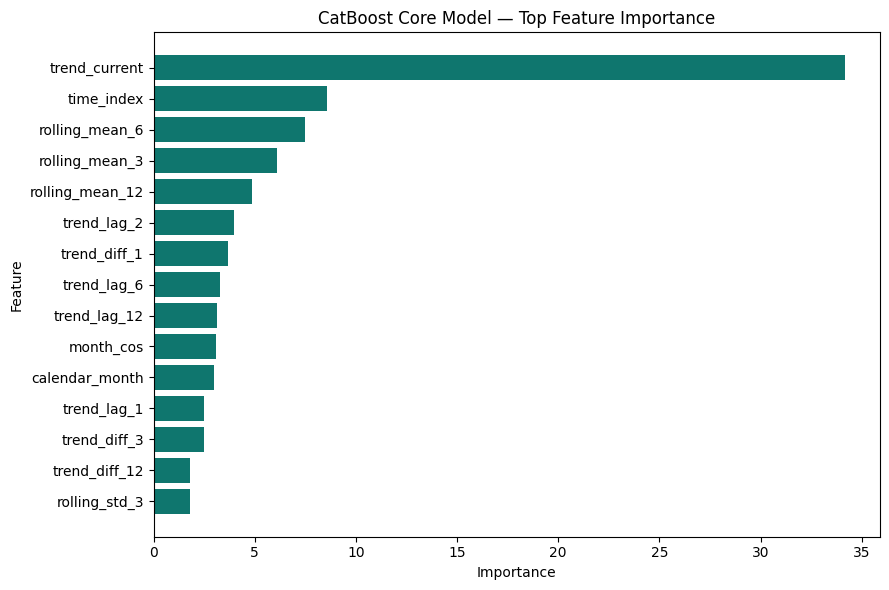

In [53]:
top_features = feature_importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1],
    color="#0f766e",
)

plt.title(
    "CatBoost Core Model — Top Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [54]:
print(
    "Best iteration:",
    core_model.get_best_iteration()
)

print(
    "Trees retained:",
    core_model.tree_count_
)

Best iteration: 318
Trees retained: 319


In [55]:
enhanced_feature_columns = (
    core_feature_columns
    + context_features
)

print(
    "Core features:",
    len(core_feature_columns)
)

print(
    "Enhanced features:",
    len(enhanced_feature_columns)
)

print("\nAdded context features:")

for feature in context_features:
    print("•", feature)

Core features: 24
Enhanced features: 32

Added context features:
• prior_year_domestic_visitors_log
• prior_year_tourism_receipts_log
• prior_year_visitor_growth_pct
• prior_year_receipts_growth_pct
• prior_year_spending_per_visitor_rm
• prior_year_average_length_of_stay
• prior_year_tourism_intensity
• prior_context_available


In [56]:
context_medians = (
    train_model_data[context_features]
    .median(numeric_only=True)
)

display(
    context_medians.to_frame(
        "training_median"
    )
)

,training_median
prior_year_domestic_visitors_log,16.151230
prior_year_tourism_receipts_log,21.942522
prior_year_visitor_growth_pct,-30.685369
prior_year_receipts_growth_pct,-42.822835
prior_year_spending_per_visitor_rm,351.161575
prior_year_average_length_of_stay,2.337808
prior_year_tourism_intensity,3.828200
prior_context_available,1.000000


In [57]:
def prepare_enhanced_features(dataframe):
    features = dataframe[
        enhanced_feature_columns
    ].copy()

    for column in categorical_features:
        features[column] = (
            features[column]
            .fillna("unknown")
            .astype(str)
        )

    for column in context_features:
        if column != "prior_context_available":
            features[column] = (
                features[column]
                .fillna(context_medians[column])
            )

    features[
        "prior_context_available"
    ] = (
        features["prior_context_available"]
        .fillna(0)
        .astype(int)
    )

    return features


X_train_enhanced = prepare_enhanced_features(
    train_model_data
)

X_validation_enhanced = prepare_enhanced_features(
    validation_model_data
)

print(
    "Training matrix:",
    X_train_enhanced.shape
)

print(
    "Validation matrix:",
    X_validation_enhanced.shape
)

print(
    "Remaining missing values:",
    X_train_enhanced.isna().sum().sum(),
    X_validation_enhanced.isna().sum().sum(),
)

Training matrix: (6271, 32)
Validation matrix: (1578, 32)
Remaining missing values: 0 0


In [58]:
train_pool_enhanced = Pool(
    data=X_train_enhanced,
    label=y_train,
    cat_features=categorical_features,
)

validation_pool_enhanced = Pool(
    data=X_validation_enhanced,
    label=y_validation,
    cat_features=categorical_features,
)

In [59]:
enhanced_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=7,
    loss_function="RMSE",
    eval_metric="MAE",
    l2_leaf_reg=5,
    random_strength=0.5,
    random_seed=42,
    has_time=True,
    early_stopping_rounds=100,
    use_best_model=True,
    task_type="CPU",
    allow_writing_files=False,
    verbose=100,
)

enhanced_model.fit(
    train_pool_enhanced,
    eval_set=validation_pool_enhanced,
)

0:	learn: 17.0699755	test: 16.8188479	best: 16.8188479 (0)	total: 28.8ms	remaining: 43.2s
100:	learn: 2.6710892	test: 2.2887422	best: 2.2887422 (100)	total: 3.44s	remaining: 47.6s
200:	learn: 2.0240647	test: 1.9796910	best: 1.9796910 (200)	total: 5.48s	remaining: 35.4s
300:	learn: 1.8668032	test: 1.9697005	best: 1.9637086 (274)	total: 6.75s	remaining: 26.9s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.963708574
bestIteration = 274

Shrink model to first 275 iterations.


CatBoostRegressor(allow_writing_files=False, depth=7, early_stopping_rounds=100, eval_metric='MAE', has_time=True, iterations=1500, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, random_strength=0.5, task_type='CPU', use_best_model=True, verbose=100)

In [60]:
enhanced_validation_predictions = (
    enhanced_model.predict(
        validation_pool_enhanced
    )
)

enhanced_validation_predictions = np.clip(
    enhanced_validation_predictions,
    0,
    100,
)

In [61]:
enhanced_metrics = calculate_metrics(
    y_validation,
    enhanced_validation_predictions,
)

enhanced_result = pd.DataFrame([
    {
        "model": "CatBoost + tourism context",
        **enhanced_metrics,
    }
])

full_validation_comparison = (
    pd.concat(
        [
            baseline_results,
            core_result,
            enhanced_result,
        ],
        ignore_index=True,
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    full_validation_comparison.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,model,MAE,RMSE,sMAPE_pct
0,CatBoost core,1.889,3.975,66.47
1,Three-month mean,1.916,4.308,33.04
2,CatBoost + tourism context,1.964,4.085,65.56
3,Last observation,2.082,4.751,29.15
4,Same month last year,2.435,5.661,29.60


In [62]:
core_mae = core_metrics["MAE"]
enhanced_mae = enhanced_metrics["MAE"]

context_improvement_pct = (
    (core_mae - enhanced_mae)
    / core_mae
    * 100
)

print(f"Core model MAE: {core_mae:.3f}")
print(
    f"Enhanced model MAE: "
    f"{enhanced_mae:.3f}"
)
print(
    f"Context improvement: "
    f"{context_improvement_pct:.2f}%"
)

Core model MAE: 1.889
Enhanced model MAE: 1.964
Context improvement: -3.93%


Positive: tourism context improved MAE.\
Negative: tourism context harmed MAE.\
Less than approximately 1%: improvement may be too small to justify additional complexity.

In [63]:
context_geo_results = []

validation_evaluation[
    "enhanced_prediction"
] = enhanced_validation_predictions

for geo_level, group in (
    validation_evaluation.groupby("geo_level")
):
    metrics = calculate_metrics(
        group[target_column],
        group["enhanced_prediction"],
    )

    context_geo_results.append({
        "geo_level": geo_level,
        "model":
            "CatBoost + tourism context",
        "rows": len(group),
        **metrics,
    })

context_geo_results = pd.DataFrame(
    context_geo_results
)

complete_geo_comparison = (
    pd.concat(
        [
            baseline_geo_results,
            core_geo_results,
            context_geo_results,
        ],
        ignore_index=True,
    )
    .sort_values(
        ["geo_level", "MAE"]
    )
    .reset_index(drop=True)
)

display(
    complete_geo_comparison.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,geo_level,model,rows,MAE,RMSE,sMAPE_pct
0,district_or_area,Three-month mean,1386,1.042,2.115,35.70
1,district_or_area,CatBoost core,1386,1.108,2.101,73.93
2,district_or_area,Last observation,1386,1.117,2.292,31.15
3,district_or_area,CatBoost + tourism context,1386,1.140,2.103,72.81
4,district_or_area,Same month last year,1386,1.266,2.742,31.30
5,state,CatBoost core,192,7.530,9.899,12.63
6,state,CatBoost + tourism context,192,7.907,10.257,13.20
7,state,Three-month mean,192,8.226,10.965,13.81
8,state,Last observation,192,9.052,12.150,14.70
9,state,Same month last year,192,10.870,14.460,17.33


In [64]:
validation_evaluation[
    "core_absolute_error"
] = np.abs(
    validation_evaluation[target_column]
    - validation_evaluation[
        "catboost_core_prediction"
    ]
)

validation_evaluation[
    "enhanced_absolute_error"
] = np.abs(
    validation_evaluation[target_column]
    - validation_evaluation[
        "enhanced_prediction"
    ]
)

series_comparison = (
    validation_evaluation.groupby(
        [
            "series_id",
            "state",
            "area",
            "geo_level",
        ]
    )
    .agg(
        core_mae=(
            "core_absolute_error",
            "mean",
        ),
        enhanced_mae=(
            "enhanced_absolute_error",
            "mean",
        ),
    )
    .reset_index()
)

series_comparison[
    "context_improved"
] = (
    series_comparison["enhanced_mae"]
    < series_comparison["core_mae"]
)

series_win_rate = (
    series_comparison[
        "context_improved"
    ].mean()
    * 100
)

print(
    f"Series improved by context: "
    f"{series_win_rate:.2f}%"
)

display(
    series_comparison.sort_values(
        "enhanced_mae"
    ).head(10)
)

Series improved by context: 36.36%


,series_id,state,area,geo_level,core_mae,enhanced_mae,context_improved
64,Sabah | district_or_area | Keningau,Sabah,Keningau,district_or_area,0.159802,0.052614,True
95,Sarawak | district_or_area | Limbang,Sarawak,Limbang,district_or_area,0.167713,0.062981,True
10,Kedah | district_or_area | Baling,Kedah,Baling,district_or_area,0.075693,0.078349,False
124,Terengganu | district_or_area | Kemaman,Terengganu,Kemaman,district_or_area,0.080715,0.110637,False
61,Sabah | district_or_area | Beaufort,Sabah,Beaufort,district_or_area,0.215954,0.148764,True
29,Melaka | district_or_area | Alor Gajah,Melaka,Alor Gajah,district_or_area,0.188451,0.197193,False
81,Sabah | district_or_area | Tuaran,Sabah,Tuaran,district_or_area,0.255235,0.268455,False
70,Sabah | district_or_area | Kudat,Sabah,Kudat,district_or_area,0.297987,0.310644,False
123,Terengganu | district_or_area | Dungun,Terengganu,Dungun,district_or_area,0.255637,0.325178,False
44,Pahang | district_or_area | Lipis,Pahang,Lipis,district_or_area,0.342136,0.331670,True


In [65]:
enhanced_importance = (
    pd.DataFrame({
        "feature":
            enhanced_feature_columns,
        "importance":
            enhanced_model.get_feature_importance(
                train_pool_enhanced
            ),
    })
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(enhanced_importance.head(20))

,feature,importance
0,trend_current,36.761463
1,rolling_mean_3,7.188500
2,time_index,6.529914
3,rolling_mean_12,5.779289
4,rolling_mean_6,5.445877
5,trend_diff_1,3.439500
6,trend_lag_6,3.379473
7,month_cos,2.950932
8,trend_lag_2,2.625477
9,rolling_std_12,2.522054


In [66]:
display(
    enhanced_importance[
        enhanced_importance["feature"]
        .isin(context_features)
    ]
)

,feature,importance
20,prior_year_average_length_of_stay,0.836886
22,prior_year_tourism_intensity,0.732808
23,prior_year_tourism_receipts_log,0.587715
24,prior_year_domestic_visitors_log,0.508476
25,prior_year_receipts_growth_pct,0.493359
26,prior_year_spending_per_visitor_rm,0.425419
28,prior_year_visitor_growth_pct,0.308939
29,prior_context_available,0.072125


## Tourism Context Ablation Conclusion

The core CatBoost model was selected.

| Model | Validation MAE |
|---|---:|
| CatBoost core | 1.889 |
| CatBoost with tourism context | 1.964 |

Adding previous-year state tourism context worsened MAE by 3.93%.
Only 36.36% of individual series improved.

The annual state-level variables likely provide insufficient temporal and
geographic detail for forecasting monthly district/area search interest.

Therefore:

- The tourism-context features are excluded from the forecasting model.
- They remain available for the separate opportunity and pressure scores.
- The core model proceeds to rolling temporal validation.

In [67]:
rolling_validation_years = [
    2022,
    2023,
    2024,
]

assert model_dataset[
    "target_month"
].dt.year.max() == 2025

In [68]:
def create_core_catboost_model():
    return CatBoostRegressor(
        iterations=1500,
        learning_rate=0.03,
        depth=7,
        loss_function="RMSE",
        eval_metric="MAE",
        l2_leaf_reg=5,
        random_strength=0.5,
        random_seed=42,
        has_time=True,
        early_stopping_rounds=100,
        use_best_model=True,
        task_type="CPU",
        allow_writing_files=False,
        verbose=False,
    )

In [69]:
rolling_results = []
rolling_predictions = []
rolling_iterations = []

for validation_year in rolling_validation_years:
    validation_start = pd.Timestamp(
        f"{validation_year}-01-01"
    )

    validation_end = pd.Timestamp(
        f"{validation_year + 1}-01-01"
    )

    fold_train = model_dataset[
        model_dataset["target_month"]
        < validation_start
    ].copy()

    fold_validation = model_dataset[
        (
            model_dataset["target_month"]
            >= validation_start
        )
        & (
            model_dataset["target_month"]
            < validation_end
        )
    ].copy()

    # Never allow 2025 into rolling validation.
    assert validation_year < 2025

    fold_train = (
        fold_train
        .sort_values(
            ["target_month", "series_id"]
        )
        .reset_index(drop=True)
    )

    fold_validation = (
        fold_validation
        .sort_values(
            ["target_month", "series_id"]
        )
        .reset_index(drop=True)
    )

    X_fold_train = prepare_catboost_features(
        fold_train,
        core_feature_columns,
        categorical_features,
    )

    X_fold_validation = prepare_catboost_features(
        fold_validation,
        core_feature_columns,
        categorical_features,
    )

    y_fold_train = fold_train[target_column]
    y_fold_validation = fold_validation[
        target_column
    ]

    fold_train_pool = Pool(
        data=X_fold_train,
        label=y_fold_train,
        cat_features=categorical_features,
    )

    fold_validation_pool = Pool(
        data=X_fold_validation,
        label=y_fold_validation,
        cat_features=categorical_features,
    )

    fold_model = create_core_catboost_model()

    fold_model.fit(
        fold_train_pool,
        eval_set=fold_validation_pool,
    )

    fold_model_predictions = np.clip(
        fold_model.predict(
            fold_validation_pool
        ),
        0,
        100,
    )

    # CatBoost result
    model_metrics = calculate_metrics(
        y_fold_validation,
        fold_model_predictions,
    )

    rolling_results.append({
        "validation_year": validation_year,
        "model": "CatBoost core",
        "train_rows": len(fold_train),
        "validation_rows":
            len(fold_validation),
        **model_metrics,
    })

    # Baseline results
    for baseline_name, prediction_column in (
        baseline_columns.items()
    ):
        baseline_metrics = calculate_metrics(
            y_fold_validation,
            fold_validation[
                prediction_column
            ],
        )

        rolling_results.append({
            "validation_year":
                validation_year,
            "model": baseline_name,
            "train_rows": len(fold_train),
            "validation_rows":
                len(fold_validation),
            **baseline_metrics,
        })

    fold_prediction_table = (
        fold_validation[
            [
                "series_id",
                "state",
                "area",
                "geo_level",
                "target_month",
                target_column,
                *baseline_columns.values(),
            ]
        ]
        .copy()
    )

    fold_prediction_table[
        "catboost_core_prediction"
    ] = fold_model_predictions

    fold_prediction_table[
        "validation_year"
    ] = validation_year

    rolling_predictions.append(
        fold_prediction_table
    )

    rolling_iterations.append({
        "validation_year": validation_year,
        "best_iteration":
            fold_model.get_best_iteration(),
        "trees_retained":
            fold_model.tree_count_,
    })

    print(
        f"Completed {validation_year}: "
        f"{len(fold_train)} training rows, "
        f"{len(fold_validation)} "
        "validation rows"
    )

Completed 2022: 3118 training rows, 1578 validation rows
Completed 2023: 4696 training rows, 1575 validation rows
Completed 2024: 6271 training rows, 1578 validation rows


In [70]:
rolling_results = pd.DataFrame(
    rolling_results
)

rolling_predictions = pd.concat(
    rolling_predictions,
    ignore_index=True,
)

rolling_iterations = pd.DataFrame(
    rolling_iterations
)

display(
    rolling_results.sort_values(
        ["validation_year", "MAE"]
    ).style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,validation_year,model,train_rows,validation_rows,MAE,RMSE,sMAPE_pct
2,2022,Three-month mean,3118,1578,2.187,4.668,28.99
1,2022,Last observation,3118,1578,2.226,4.805,24.82
0,2022,CatBoost core,3118,1578,3.214,6.548,63.20
3,2022,Same month last year,3118,1578,6.757,13.551,63.06
4,2023,CatBoost core,4696,1575,1.708,3.986,58.78
6,2023,Three-month mean,4696,1575,1.750,4.195,28.05
5,2023,Last observation,4696,1575,1.771,4.498,24.87
7,2023,Same month last year,4696,1575,2.721,5.835,28.07
8,2024,CatBoost core,6271,1578,1.889,3.975,66.47
10,2024,Three-month mean,6271,1578,1.916,4.308,33.04


In [71]:
catboost_fold_results = (
    rolling_results[
        rolling_results["model"]
        == "CatBoost core"
    ][
        [
            "validation_year",
            "MAE",
            "RMSE",
            "sMAPE_pct",
        ]
    ]
    .rename(columns={
        "MAE": "catboost_mae",
        "RMSE": "catboost_rmse",
        "sMAPE_pct": "catboost_smape",
    })
)

baseline_fold_results = (
    rolling_results[
        rolling_results["model"]
        != "CatBoost core"
    ]
    .sort_values(
        ["validation_year", "MAE"]
    )
    .groupby(
        "validation_year",
        as_index=False,
    )
    .first()
    [
        [
            "validation_year",
            "model",
            "MAE",
            "RMSE",
            "sMAPE_pct",
        ]
    ]
    .rename(columns={
        "model": "best_baseline",
        "MAE": "best_baseline_mae",
        "RMSE": "best_baseline_rmse",
        "sMAPE_pct":
            "best_baseline_smape",
    })
)

fold_comparison = (
    catboost_fold_results.merge(
        baseline_fold_results,
        on="validation_year",
        validate="one_to_one",
    )
)

fold_comparison[
    "mae_improvement_pct"
] = (
    (
        fold_comparison[
            "best_baseline_mae"
        ]
        - fold_comparison["catboost_mae"]
    )
    / fold_comparison[
        "best_baseline_mae"
    ]
    * 100
)

fold_comparison[
    "catboost_wins"
] = (
    fold_comparison["catboost_mae"]
    < fold_comparison["best_baseline_mae"]
)

display(
    fold_comparison.style.format({
        "catboost_mae": "{:.3f}",
        "best_baseline_mae": "{:.3f}",
        "mae_improvement_pct": "{:.2f}%",
    })
)

,validation_year,catboost_mae,catboost_rmse,catboost_smape,best_baseline,best_baseline_mae,best_baseline_rmse,best_baseline_smape,mae_improvement_pct,catboost_wins
0,2022,3.214,6.547965,63.197811,Three-month mean,2.187,4.667610,28.991937,-46.96%,False
1,2023,1.708,3.985666,58.778936,Three-month mean,1.750,4.195496,28.047086,2.37%,True
2,2024,1.889,3.974723,66.471517,Three-month mean,1.916,4.307951,33.038432,1.39%,True


In [72]:
years_won = int(
    fold_comparison[
        "catboost_wins"
    ].sum()
)

mean_improvement = (
    fold_comparison[
        "mae_improvement_pct"
    ].mean()
)

worst_improvement = (
    fold_comparison[
        "mae_improvement_pct"
    ].min()
)

print(
    f"CatBoost won {years_won} of "
    f"{len(fold_comparison)} folds."
)

print(
    f"Mean MAE improvement: "
    f"{mean_improvement:.2f}%"
)

print(
    f"Worst-fold improvement: "
    f"{worst_improvement:.2f}%"
)

CatBoost won 2 of 3 folds.
Mean MAE improvement: -14.40%
Worst-fold improvement: -46.96%


In [73]:
rolling_average_results = (
    rolling_results.groupby("model")
    .agg(
        mean_MAE=("MAE", "mean"),
        std_MAE=("MAE", "std"),
        mean_RMSE=("RMSE", "mean"),
        mean_sMAPE=("sMAPE_pct", "mean"),
    )
    .sort_values("mean_MAE")
    .reset_index()
)

display(
    rolling_average_results.style.format({
        "mean_MAE": "{:.3f}",
        "std_MAE": "{:.3f}",
        "mean_RMSE": "{:.3f}",
        "mean_sMAPE": "{:.2f}",
    })
)

,model,mean_MAE,std_MAE,mean_RMSE,mean_sMAPE
0,Three-month mean,1.951,0.221,4.390,30.03
1,Last observation,2.026,0.233,4.685,26.28
2,CatBoost core,2.271,0.822,4.836,62.82
3,Same month last year,3.971,2.417,8.349,40.25


In [74]:
rolling_geo_results = []

prediction_methods = {
    "CatBoost core":
        "catboost_core_prediction",
    **baseline_columns,
}

for (
    validation_year,
    geo_level,
), group in rolling_predictions.groupby(
    ["validation_year", "geo_level"]
):
    for model_name, prediction_column in (
        prediction_methods.items()
    ):
        metrics = calculate_metrics(
            group[target_column],
            group[prediction_column],
        )

        rolling_geo_results.append({
            "validation_year":
                validation_year,
            "geo_level": geo_level,
            "model": model_name,
            "rows": len(group),
            **metrics,
        })

rolling_geo_results = pd.DataFrame(
    rolling_geo_results
)

display(
    rolling_geo_results.sort_values(
        [
            "validation_year",
            "geo_level",
            "MAE",
        ]
    ).style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,validation_year,geo_level,model,rows,MAE,RMSE,sMAPE_pct
1,2022,district_or_area,Last observation,1386,1.317,2.775,26.47
2,2022,district_or_area,Three-month mean,1386,1.318,2.898,31.29
0,2022,district_or_area,CatBoost core,1386,2.008,4.330,69.44
3,2022,district_or_area,Same month last year,1386,4.421,9.757,65.67
6,2022,state,Three-month mean,192,8.458,10.882,12.39
5,2022,state,Last observation,192,8.792,11.583,12.88
4,2022,state,CatBoost core,192,11.918,14.731,18.14
7,2022,state,Same month last year,192,23.620,28.670,44.23
9,2023,district_or_area,Last observation,1383,0.913,1.930,26.67
10,2023,district_or_area,Three-month mean,1383,0.920,1.858,30.30


In [75]:
rolling_geo_average = (
    rolling_geo_results.groupby(
        ["geo_level", "model"]
    )
    .agg(
        mean_MAE=("MAE", "mean"),
        std_MAE=("MAE", "std"),
        mean_RMSE=("RMSE", "mean"),
    )
    .reset_index()
    .sort_values(
        ["geo_level", "mean_MAE"]
    )
)

display(
    rolling_geo_average.style.format({
        "mean_MAE": "{:.3f}",
        "std_MAE": "{:.3f}",
        "mean_RMSE": "{:.3f}",
    })
)

,geo_level,model,mean_MAE,std_MAE,mean_RMSE
3,district_or_area,Three-month mean,1.093,0.204,2.291
1,district_or_area,Last observation,1.115,0.202,2.333
0,district_or_area,CatBoost core,1.366,0.560,2.814
2,district_or_area,Same month last year,2.433,1.730,5.336
7,state,Three-month mean,8.137,0.374,10.926
5,state,Last observation,8.599,0.574,11.842
4,state,CatBoost core,8.796,2.721,11.563
6,state,Same month last year,15.068,7.407,18.980


In [76]:
display(rolling_iterations)

print(
    "Median best iteration:",
    int(
        rolling_iterations[
            "best_iteration"
        ].median()
    )
)

,validation_year,best_iteration,trees_retained
0,2022,237,238
1,2023,559,560
2,2024,318,319


Median best iteration: 318


## Rolling Validation Conclusion

The direct global CatBoost model was rejected.

Although CatBoost beat the best baseline in 2023 and 2024, it performed
46.96% worse in 2022. Its average MAE across all folds was 2.271,
compared with 1.951 for the three-month rolling mean.

The global model was also worse on average for both geographic levels:

- District/area: CatBoost 1.366 vs three-month mean 1.093
- State: CatBoost 8.796 vs three-month mean 8.137

The improvement observed in the 2024 validation split was not stable
across time. Therefore, the direct CatBoost model is not selected.

In [77]:
model_dataset[
    "residual_target"
] = (
    model_dataset[target_column]
    - model_dataset["rolling_mean_3"]
)

print(
    model_dataset[
        "residual_target"
    ].describe()
)

count    9433.000000
mean       -0.033641
std         6.338104
min       -53.000000
25%        -0.666667
50%         0.000000
75%         0.666667
max        78.000000
Name: residual_target, dtype: float64


In [78]:
residual_results = []
residual_predictions = []
residual_iterations = []

for validation_year in rolling_validation_years:
    validation_start = pd.Timestamp(
        f"{validation_year}-01-01"
    )

    validation_end = pd.Timestamp(
        f"{validation_year + 1}-01-01"
    )

    fold_train = model_dataset[
        model_dataset["target_month"]
        < validation_start
    ].copy()

    fold_validation = model_dataset[
        (
            model_dataset["target_month"]
            >= validation_start
        )
        & (
            model_dataset["target_month"]
            < validation_end
        )
    ].copy()

    fold_train = (
        fold_train
        .sort_values(
            ["target_month", "series_id"]
        )
        .reset_index(drop=True)
    )

    fold_validation = (
        fold_validation
        .sort_values(
            ["target_month", "series_id"]
        )
        .reset_index(drop=True)
    )

    X_fold_train = prepare_catboost_features(
        fold_train,
        core_feature_columns,
        categorical_features,
    )

    X_fold_validation = prepare_catboost_features(
        fold_validation,
        core_feature_columns,
        categorical_features,
    )

    residual_train_pool = Pool(
        data=X_fold_train,
        label=fold_train["residual_target"],
        cat_features=categorical_features,
    )

    residual_validation_pool = Pool(
        data=X_fold_validation,
        label=fold_validation[
            "residual_target"
        ],
        cat_features=categorical_features,
    )

    residual_model = (
        create_core_catboost_model()
    )

    residual_model.fit(
        residual_train_pool,
        eval_set=residual_validation_pool,
    )

    predicted_correction = (
        residual_model.predict(
            residual_validation_pool
        )
    )

    final_prediction = np.clip(
        fold_validation["rolling_mean_3"]
        + predicted_correction,
        0,
        100,
    )

    metrics = calculate_metrics(
        fold_validation[target_column],
        final_prediction,
    )

    residual_results.append({
        "validation_year":
            validation_year,
        "model":
            "CatBoost residual correction",
        "train_rows": len(fold_train),
        "validation_rows":
            len(fold_validation),
        **metrics,
    })

    prediction_table = (
        fold_validation[
            [
                "series_id",
                "state",
                "area",
                "geo_level",
                "target_month",
                target_column,
                "rolling_mean_3",
            ]
        ]
        .copy()
    )

    prediction_table[
        "predicted_correction"
    ] = predicted_correction

    prediction_table[
        "residual_prediction"
    ] = final_prediction

    prediction_table[
        "validation_year"
    ] = validation_year

    residual_predictions.append(
        prediction_table
    )

    residual_iterations.append({
        "validation_year":
            validation_year,
        "best_iteration":
            residual_model.get_best_iteration(),
        "trees_retained":
            residual_model.tree_count_,
    })

    print(
        f"Completed residual fold "
        f"{validation_year}"
    )

Completed residual fold 2022
Completed residual fold 2023
Completed residual fold 2024


In [79]:
residual_results = pd.DataFrame(
    residual_results
)

residual_predictions = pd.concat(
    residual_predictions,
    ignore_index=True,
)

residual_iterations = pd.DataFrame(
    residual_iterations
)

display(
    residual_results.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,validation_year,model,train_rows,validation_rows,MAE,RMSE,sMAPE_pct
0,2022,CatBoost residual correction,3118,1578,2.282,4.679,62.80
1,2023,CatBoost residual correction,4696,1575,1.735,4.092,59.85
2,2024,CatBoost residual correction,6271,1578,1.852,4.063,56.80


In [80]:
rolling_three_month = (
    rolling_results[
        rolling_results["model"]
        == "Three-month mean"
    ][
        [
            "validation_year",
            "MAE",
            "RMSE",
        ]
    ]
    .rename(columns={
        "MAE": "baseline_mae",
        "RMSE": "baseline_rmse",
    })
)

residual_fold_comparison = (
    residual_results[
        [
            "validation_year",
            "MAE",
            "RMSE",
            "sMAPE_pct",
        ]
    ]
    .rename(columns={
        "MAE": "residual_mae",
        "RMSE": "residual_rmse",
        "sMAPE_pct": "residual_smape",
    })
    .merge(
        rolling_three_month,
        on="validation_year",
        validate="one_to_one",
    )
)

residual_fold_comparison[
    "mae_improvement_pct"
] = (
    (
        residual_fold_comparison[
            "baseline_mae"
        ]
        - residual_fold_comparison[
            "residual_mae"
        ]
    )
    / residual_fold_comparison[
        "baseline_mae"
    ]
    * 100
)

residual_fold_comparison[
    "residual_wins"
] = (
    residual_fold_comparison[
        "residual_mae"
    ]
    < residual_fold_comparison[
        "baseline_mae"
    ]
)

display(
    residual_fold_comparison.style.format({
        "residual_mae": "{:.3f}",
        "baseline_mae": "{:.3f}",
        "mae_improvement_pct": "{:.2f}%",
    })
)

,validation_year,residual_mae,residual_rmse,residual_smape,baseline_mae,baseline_rmse,mae_improvement_pct,residual_wins
0,2022,2.282,4.679238,62.795343,2.187,4.667610,-4.34%,False
1,2023,1.735,4.091581,59.854671,1.750,4.195496,0.85%,True
2,2024,1.852,4.062841,56.796072,1.916,4.307951,3.32%,True


In [81]:
residual_years_won = int(
    residual_fold_comparison[
        "residual_wins"
    ].sum()
)

residual_mean_improvement = (
    residual_fold_comparison[
        "mae_improvement_pct"
    ].mean()
)

residual_worst_improvement = (
    residual_fold_comparison[
        "mae_improvement_pct"
    ].min()
)

print(
    f"Residual model won "
    f"{residual_years_won} of 3 folds."
)

print(
    f"Mean improvement: "
    f"{residual_mean_improvement:.2f}%"
)

print(
    f"Worst-fold improvement: "
    f"{residual_worst_improvement:.2f}%"
)

Residual model won 2 of 3 folds.
Mean improvement: -0.06%
Worst-fold improvement: -4.34%


In [82]:
residual_geo_results = []

for (
    validation_year,
    geo_level,
), group in residual_predictions.groupby(
    ["validation_year", "geo_level"]
):
    baseline_metrics = calculate_metrics(
        group[target_column],
        group["rolling_mean_3"],
    )

    residual_metrics = calculate_metrics(
        group[target_column],
        group["residual_prediction"],
    )

    residual_geo_results.extend([
        {
            "validation_year":
                validation_year,
            "geo_level": geo_level,
            "model": "Three-month mean",
            **baseline_metrics,
        },
        {
            "validation_year":
                validation_year,
            "geo_level": geo_level,
            "model":
                "CatBoost residual correction",
            **residual_metrics,
        },
    ])

residual_geo_results = pd.DataFrame(
    residual_geo_results
)

residual_geo_average = (
    residual_geo_results.groupby(
        ["geo_level", "model"]
    )
    .agg(
        mean_MAE=("MAE", "mean"),
        std_MAE=("MAE", "std"),
        mean_RMSE=("RMSE", "mean"),
    )
    .reset_index()
    .sort_values(
        ["geo_level", "mean_MAE"]
    )
)

display(
    residual_geo_average.style.format({
        "mean_MAE": "{:.3f}",
        "std_MAE": "{:.3f}",
        "mean_RMSE": "{:.3f}",
    })
)

,geo_level,model,mean_MAE,std_MAE,mean_RMSE
1,district_or_area,Three-month mean,1.093,0.204,2.291
0,district_or_area,CatBoost residual correction,1.142,0.252,2.288
2,state,CatBoost residual correction,7.834,0.556,10.563
3,state,Three-month mean,8.137,0.374,10.926


In [83]:
residual_predictions[
    "hybrid_prediction"
] = np.where(
    residual_predictions["geo_level"]
    == "state",

    residual_predictions[
        "residual_prediction"
    ],

    residual_predictions[
        "rolling_mean_3"
    ],
)

In [84]:
residual_predictions[
    "hybrid_method"
] = np.where(
    residual_predictions["geo_level"]
    == "state",

    "CatBoost residual correction",

    "Three-month mean",
)

display(
    residual_predictions[
        [
            "geo_level",
            "hybrid_method",
        ]
    ]
    .drop_duplicates()
    .sort_values("geo_level")
)

,geo_level,hybrid_method
0,district_or_area,Three-month mean
9,state,CatBoost residual correction


In [85]:
hybrid_rolling_results = []

for validation_year, group in (
    residual_predictions.groupby(
        "validation_year"
    )
):
    hybrid_metrics = calculate_metrics(
        group[target_column],
        group["hybrid_prediction"],
    )

    baseline_metrics = calculate_metrics(
        group[target_column],
        group["rolling_mean_3"],
    )

    hybrid_rolling_results.append({
        "validation_year":
            validation_year,
        "method":
            "Segmented hybrid",
        **hybrid_metrics,
    })

    hybrid_rolling_results.append({
        "validation_year":
            validation_year,
        "method":
            "Three-month mean",
        **baseline_metrics,
    })

hybrid_rolling_results = pd.DataFrame(
    hybrid_rolling_results
)

display(
    hybrid_rolling_results.sort_values(
        ["validation_year", "MAE"]
    ).style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,validation_year,method,MAE,RMSE,sMAPE_pct
1,2022,Three-month mean,2.187,4.668,28.99
0,2022,Segmented hybrid,2.189,4.667,28.99
2,2023,Segmented hybrid,1.719,4.107,28.00
3,2023,Three-month mean,1.750,4.195,28.05
4,2024,Segmented hybrid,1.834,4.060,32.90
5,2024,Three-month mean,1.916,4.308,33.04


In [86]:
hybrid_results_wide = (
    hybrid_rolling_results.pivot(
        index="validation_year",
        columns="method",
        values=["MAE", "RMSE", "sMAPE_pct"],
    )
)

hybrid_fold_comparison = pd.DataFrame({
    "validation_year":
        hybrid_results_wide.index,

    "hybrid_mae":
        hybrid_results_wide[
            ("MAE", "Segmented hybrid")
        ].values,

    "baseline_mae":
        hybrid_results_wide[
            ("MAE", "Three-month mean")
        ].values,

    "hybrid_rmse":
        hybrid_results_wide[
            ("RMSE", "Segmented hybrid")
        ].values,

    "baseline_rmse":
        hybrid_results_wide[
            ("RMSE", "Three-month mean")
        ].values,
})

hybrid_fold_comparison[
    "mae_improvement_pct"
] = (
    (
        hybrid_fold_comparison[
            "baseline_mae"
        ]
        - hybrid_fold_comparison[
            "hybrid_mae"
        ]
    )
    / hybrid_fold_comparison[
        "baseline_mae"
    ]
    * 100
)

hybrid_fold_comparison[
    "hybrid_wins"
] = (
    hybrid_fold_comparison[
        "hybrid_mae"
    ]
    < hybrid_fold_comparison[
        "baseline_mae"
    ]
)

display(
    hybrid_fold_comparison.style.format({
        "hybrid_mae": "{:.3f}",
        "baseline_mae": "{:.3f}",
        "hybrid_rmse": "{:.3f}",
        "baseline_rmse": "{:.3f}",
        "mae_improvement_pct": "{:.2f}%",
    })
)

,validation_year,hybrid_mae,baseline_mae,hybrid_rmse,baseline_rmse,mae_improvement_pct,hybrid_wins
0,2022,2.189,2.187,4.667,4.668,-0.09%,False
1,2023,1.719,1.750,4.107,4.195,1.75%,True
2,2024,1.834,1.916,4.060,4.308,4.27%,True


In [87]:
segment_comparison = (
    residual_geo_results.pivot_table(
        index=[
            "validation_year",
            "geo_level",
        ],
        columns="model",
        values="MAE",
    )
    .reset_index()
)

segment_comparison[
    "residual_improvement_pct"
] = (
    (
        segment_comparison[
            "Three-month mean"
        ]
        - segment_comparison[
            "CatBoost residual correction"
        ]
    )
    / segment_comparison[
        "Three-month mean"
    ]
    * 100
)

segment_comparison[
    "preferred_method"
] = np.where(
    segment_comparison[
        "CatBoost residual correction"
    ]
    < segment_comparison[
        "Three-month mean"
    ],

    "Residual CatBoost",

    "Three-month mean",
)

display(
    segment_comparison.style.format({
        "CatBoost residual correction":
            "{:.3f}",
        "Three-month mean":
            "{:.3f}",
        "residual_improvement_pct":
            "{:.2f}%",
    })
)

model,validation_year,geo_level,CatBoost residual correction,Three-month mean,residual_improvement_pct,preferred_method
0,2022,district_or_area,1.424,1.318,-8.03%,Three-month mean
1,2022,state,8.475,8.458,-0.20%,Three-month mean
2,2023,district_or_area,0.938,0.920,-1.94%,Three-month mean
3,2023,state,7.475,7.726,3.25%,Residual CatBoost
4,2024,district_or_area,1.063,1.042,-1.99%,Three-month mean
5,2024,state,7.553,8.226,8.18%,Residual CatBoost


In [88]:
hybrid_years_won = int(
    hybrid_fold_comparison[
        "hybrid_wins"
    ].sum()
)

hybrid_mean_improvement = (
    hybrid_fold_comparison[
        "mae_improvement_pct"
    ].mean()
)

hybrid_worst_improvement = (
    hybrid_fold_comparison[
        "mae_improvement_pct"
    ].min()
)

hybrid_mean_mae = (
    hybrid_fold_comparison[
        "hybrid_mae"
    ].mean()
)

baseline_mean_mae = (
    hybrid_fold_comparison[
        "baseline_mae"
    ].mean()
)

print(
    f"Hybrid won {hybrid_years_won} "
    "of 3 folds."
)

print(
    f"Hybrid mean MAE: "
    f"{hybrid_mean_mae:.3f}"
)

print(
    f"Baseline mean MAE: "
    f"{baseline_mean_mae:.3f}"
)

print(
    f"Mean improvement: "
    f"{hybrid_mean_improvement:.2f}%"
)

print(
    f"Worst-fold improvement: "
    f"{hybrid_worst_improvement:.2f}%"
)

Hybrid won 2 of 3 folds.
Hybrid mean MAE: 1.914
Baseline mean MAE: 1.951
Mean improvement: 1.98%
Worst-fold improvement: -0.09%


# Locked Forecasting Architecture

The segmented hybrid model was selected before opening the 2025 test set.

## Decision rule

- State series: CatBoost residual correction added to the three-month mean.
- District/area series: three-month mean.
- Constant or insufficient-signal series: three-month mean.

## Rolling-validation evidence

- Hybrid won 2 of 3 folds.
- Mean MAE improvement: 1.98%.
- Worst-fold change: -0.09%.
- State residual correction improved performance in 2023 and 2024.
- Residual correction consistently harmed district/area forecasting.

No model configuration will be changed after viewing the 2025 test results.

In [89]:
display(residual_iterations)

final_iterations = int(
    round(
        residual_iterations[
            "trees_retained"
        ].median()
    )
)

assert final_iterations > 0

print(
    "Final number of trees:",
    final_iterations
)

,validation_year,best_iteration,trees_retained
0,2022,0,1
1,2023,12,13
2,2024,314,315


Final number of trees: 13


In [90]:
final_train_data = (
    model_dataset[
        model_dataset["target_month"]
        < pd.Timestamp("2025-01-01")
    ]
    .sort_values(
        ["target_month", "series_id"]
    )
    .reset_index(drop=True)
)

final_test_data = (
    model_dataset[
        (
            model_dataset["target_month"]
            >= pd.Timestamp("2025-01-01")
        )
        & (
            model_dataset["target_month"]
            < pd.Timestamp("2026-01-01")
        )
    ]
    .sort_values(
        ["target_month", "series_id"]
    )
    .reset_index(drop=True)
)

print(
    "Final training rows:",
    len(final_train_data)
)

print(
    "Final test rows:",
    len(final_test_data)
)

print(
    "Training target range:",
    final_train_data["target_month"].min(),
    "to",
    final_train_data["target_month"].max(),
)

print(
    "Test target range:",
    final_test_data["target_month"].min(),
    "to",
    final_test_data["target_month"].max(),
)

Final training rows: 7849
Final test rows: 1584
Training target range: 2020-01-01 00:00:00 to 2024-12-01 00:00:00
Test target range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00


In [91]:
X_final_train = prepare_catboost_features(
    final_train_data,
    core_feature_columns,
    categorical_features,
)

X_final_test = prepare_catboost_features(
    final_test_data,
    core_feature_columns,
    categorical_features,
)

y_final_residual_train = (
    final_train_data["residual_target"]
)

y_final_test = final_test_data[
    target_column
]

In [92]:
final_train_pool = Pool(
    data=X_final_train,
    label=y_final_residual_train,
    cat_features=categorical_features,
)

final_test_pool = Pool(
    data=X_final_test,
    cat_features=categorical_features,
)

In [93]:
final_residual_model = CatBoostRegressor(
    iterations=final_iterations,
    learning_rate=0.03,
    depth=7,
    loss_function="RMSE",
    eval_metric="MAE",
    l2_leaf_reg=5,
    random_strength=0.5,
    random_seed=42,
    has_time=True,
    use_best_model=False,
    task_type="CPU",
    allow_writing_files=False,
    verbose=100,
)

final_residual_model.fit(
    final_train_pool
)

0:	learn: 2.7431943	total: 10.6ms	remaining: 127ms
12:	learn: 2.5528834	total: 116ms	remaining: 0us


CatBoostRegressor(allow_writing_files=False, depth=7, eval_metric='MAE', has_time=True, iterations=13, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, random_strength=0.5, task_type='CPU', use_best_model=False, verbose=100)

In [94]:
test_residual_correction = (
    final_residual_model.predict(
        final_test_pool
    )
)

test_state_prediction = np.clip(
    final_test_data["rolling_mean_3"]
    + test_residual_correction,
    0,
    100,
)

test_hybrid_prediction = np.where(
    final_test_data["geo_level"]
    == "state",

    test_state_prediction,

    final_test_data["rolling_mean_3"],
)

In [95]:
district_mask = (
    final_test_data["geo_level"]
    == "district_or_area"
)

assert np.allclose(
    test_hybrid_prediction[district_mask],
    final_test_data.loc[
        district_mask,
        "rolling_mean_3",
    ],
)

print(
    "✓ District/area predictions use "
    "the three-month mean"
)

print(
    "✓ State predictions use residual "
    "CatBoost correction"
)

✓ District/area predictions use the three-month mean
✓ State predictions use residual CatBoost correction


In [96]:
test_comparison_rows = []

test_methods = {
    "Segmented hybrid":
        test_hybrid_prediction,

    "Three-month mean":
        final_test_data[
            "rolling_mean_3"
        ].to_numpy(),

    "Last observation":
        final_test_data[
            "trend_current"
        ].to_numpy(),

    "Same month last year":
        final_test_data[
            "baseline_same_month_last_year"
        ].to_numpy(),
}

for method_name, predictions in (
    test_methods.items()
):
    metrics = calculate_metrics(
        y_final_test,
        predictions,
    )

    test_comparison_rows.append({
        "method": method_name,
        **metrics,
    })

final_test_results = (
    pd.DataFrame(test_comparison_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    final_test_results.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,method,MAE,RMSE,sMAPE_pct
0,Same month last year,1.754,3.755,27.88
1,Segmented hybrid,1.821,4.129,37.15
2,Three-month mean,1.854,4.238,37.21
3,Last observation,1.933,4.316,28.04


In [97]:
hybrid_test_mae = final_test_results.loc[
    final_test_results["method"]
    == "Segmented hybrid",
    "MAE",
].iloc[0]

baseline_test_mae = final_test_results.loc[
    final_test_results["method"]
    == "Three-month mean",
    "MAE",
].iloc[0]

final_test_improvement = (
    (baseline_test_mae - hybrid_test_mae)
    / baseline_test_mae
    * 100
)

print(
    f"Hybrid test MAE: "
    f"{hybrid_test_mae:.3f}"
)

print(
    f"Baseline test MAE: "
    f"{baseline_test_mae:.3f}"
)

print(
    f"Final test improvement: "
    f"{final_test_improvement:.2f}%"
)

Hybrid test MAE: 1.821
Baseline test MAE: 1.854
Final test improvement: 1.82%


In [98]:
final_test_evaluation = (
    final_test_data[
        [
            "series_id",
            "state",
            "area",
            "geo_level",
            "target_month",
            target_column,
            "rolling_mean_3",
        ]
    ]
    .copy()
)

final_test_evaluation[
    "hybrid_prediction"
] = test_hybrid_prediction

test_geo_results = []

for geo_level, group in (
    final_test_evaluation.groupby(
        "geo_level"
    )
):
    for method, prediction_column in {
        "Segmented hybrid":
            "hybrid_prediction",

        "Three-month mean":
            "rolling_mean_3",
    }.items():
        metrics = calculate_metrics(
            group[target_column],
            group[prediction_column],
        )

        test_geo_results.append({
            "geo_level": geo_level,
            "method": method,
            "rows": len(group),
            **metrics,
        })

test_geo_results = pd.DataFrame(
    test_geo_results
)

display(
    test_geo_results.sort_values(
        ["geo_level", "MAE"]
    ).style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE_pct": "{:.2f}",
    })
)

,geo_level,method,rows,MAE,RMSE,sMAPE_pct
0,district_or_area,Segmented hybrid,1392,1.075,2.345,40.52
1,district_or_area,Three-month mean,1392,1.075,2.345,40.52
2,state,Segmented hybrid,192,7.227,10.038,12.75
3,state,Three-month mean,192,7.505,10.408,13.21


# Final Forecasting Decision

The segmented hybrid forecasting architecture was selected.

## Final 2025 test performance

| Method | MAE | RMSE |
|---|---:|---:|
| Segmented hybrid | 1.821 | 4.129 |
| Three-month mean | 1.854 | 4.238 |

The hybrid reduced overall MAE by 1.82% and RMSE by approximately 2.57%.

For state series, residual CatBoost reduced MAE from 7.505 to 7.227,
an improvement of approximately 3.70%.

District/area predictions remained identical to the three-month rolling
mean by design.

## Final architecture

- State series: three-month mean plus CatBoost residual correction.
- District/area series: three-month mean.
- Constant or insufficient-signal series: three-month mean.

The same-month-last-year baseline achieved a lower MAE on the isolated
2025 test set. However, it was rejected because rolling validation showed
that it was highly unstable across years. It was not selected post hoc
after observing the test results.

No further model tuning will use the 2025 test set.

In [99]:
from datetime import datetime, timezone
from pathlib import Path
import json
import shutil

ARTIFACT_DIR = (
    REPO_DIR / "ml" / "artifacts"
)

ML_OUTPUT_DIR = (
    REPO_DIR / "ml" / "outputs"
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ML_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Artifacts:", ARTIFACT_DIR)
print("Outputs:", ML_OUTPUT_DIR)

Artifacts: /content/Databladez_Tourism/ml/artifacts
Outputs: /content/Databladez_Tourism/ml/outputs


In [100]:
deployment_train_data = (
    model_dataset
    .sort_values(
        ["target_month", "series_id"]
    )
    .reset_index(drop=True)
)

X_deployment_train = (
    prepare_catboost_features(
        deployment_train_data,
        core_feature_columns,
        categorical_features,
    )
)

deployment_train_pool = Pool(
    data=X_deployment_train,
    label=deployment_train_data[
        "residual_target"
    ],
    cat_features=categorical_features,
)

deployment_model = CatBoostRegressor(
    iterations=final_iterations,
    learning_rate=0.03,
    depth=7,
    loss_function="RMSE",
    eval_metric="MAE",
    l2_leaf_reg=5,
    random_strength=0.5,
    random_seed=42,
    has_time=True,
    use_best_model=False,
    task_type="CPU",
    allow_writing_files=False,
    verbose=100,
)

deployment_model.fit(
    deployment_train_pool
)

print(
    "Deployment training rows:",
    len(deployment_train_data)
)

print(
    "Training target end:",
    deployment_train_data[
        "target_month"
    ].max()
)

0:	learn: 2.5937870	total: 11.7ms	remaining: 141ms
12:	learn: 2.4305089	total: 118ms	remaining: 0us
Deployment training rows: 9433
Training target end: 2025-12-01 00:00:00


In [101]:
MODEL_PATH = (
    ARTIFACT_DIR
    / "tourism_demand_residual_model.cbm"
)

deployment_model.save_model(
    str(MODEL_PATH)
)

print(
    "Saved model:",
    MODEL_PATH
)

print(
    "Model size:",
    f"{MODEL_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

Saved model: /content/Databladez_Tourism/ml/artifacts/tourism_demand_residual_model.cbm
Model size: 0.03 MB


In [102]:
loaded_model = CatBoostRegressor()

loaded_model.load_model(
    str(MODEL_PATH)
)

sample_features = (
    X_deployment_train.head(20)
)

original_predictions = (
    deployment_model.predict(
        sample_features
    )
)

loaded_predictions = (
    loaded_model.predict(
        sample_features
    )
)

assert np.allclose(
    original_predictions,
    loaded_predictions,
)

print(
    "✓ Saved model reloads correctly"
)

✓ Saved model reloads correctly


In [103]:
all_series_history = (
    trends_clean
    .sort_values(
        ["series_id", "month"]
    )
    .reset_index(drop=True)
    .copy()
)

all_series_history[
    "rolling_mean_3"
] = (
    all_series_history
    .groupby("series_id")[
        "trend_index"
    ]
    .transform(
        lambda series:
        series.rolling(
            window=3,
            min_periods=1,
        ).mean()
    )
)

latest_all_series = (
    all_series_history
    .groupby(
        "series_id",
        as_index=False,
    )
    .tail(1)
    .copy()
)

latest_all_series = (
    latest_all_series.merge(
        series_registry[
            [
                "series_id",
                "eligible_for_training",
                "exclusion_reason",
            ]
        ],
        on="series_id",
        how="left",
        validate="one_to_one",
    )
)

print(
    "Latest series available:",
    len(latest_all_series)
)

assert len(latest_all_series) == 167

Latest series available: 167


In [104]:
latest_state_features = (
    feature_data[
        feature_data["geo_level"]
        == "state"
    ]
    .sort_values(
        ["series_id", "month"]
    )
    .groupby(
        "series_id",
        as_index=False,
    )
    .tail(1)
    .reset_index(drop=True)
)

assert len(latest_state_features) == 16

X_latest_states = (
    prepare_catboost_features(
        latest_state_features,
        core_feature_columns,
        categorical_features,
    )
)

latest_state_features[
    "predicted_residual"
] = deployment_model.predict(
    X_latest_states
)

latest_state_features[
    "state_hybrid_forecast"
] = np.clip(
    latest_state_features[
        "rolling_mean_3"
    ]
    + latest_state_features[
        "predicted_residual"
    ],
    0,
    100,
)

state_forecast_map = dict(
    zip(
        latest_state_features[
            "series_id"
        ],
        latest_state_features[
            "state_hybrid_forecast"
        ],
    )
)

In [105]:
forecast_output = latest_all_series[
    [
        "series_id",
        "state",
        "area",
        "geo_level",
        "month",
        "trend_index",
        "rolling_mean_3",
        "eligible_for_training",
        "exclusion_reason",
    ]
].copy()

forecast_output = forecast_output.rename(
    columns={
        "month":
            "latest_observed_month",
        "trend_index":
            "latest_trend_index",
        "rolling_mean_3":
            "three_month_mean",
    }
)

forecast_output[
    "forecast_month"
] = (
    forecast_output[
        "latest_observed_month"
    ]
    + pd.offsets.MonthBegin(1)
)

forecast_output[
    "forecast_trend_index"
] = forecast_output[
    "three_month_mean"
]

state_mask = (
    forecast_output["geo_level"]
    == "state"
)

forecast_output.loc[
    state_mask,
    "forecast_trend_index",
] = (
    forecast_output.loc[
        state_mask,
        "series_id",
    ]
    .map(state_forecast_map)
)

forecast_output[
    "forecast_method"
] = np.where(
    state_mask,
    "catboost_residual_hybrid",
    "three_month_mean",
)

forecast_output.loc[
    forecast_output[
        "eligible_for_training"
    ] == False,
    "forecast_method",
] = "three_month_mean_insufficient_signal"

forecast_output[
    "forecast_change_points"
] = (
    forecast_output[
        "forecast_trend_index"
    ]
    - forecast_output[
        "latest_trend_index"
    ]
)

forecast_output[
    "momentum_direction"
] = np.select(
    [
        forecast_output[
            "forecast_change_points"
        ] >= 2,

        forecast_output[
            "forecast_change_points"
        ] <= -2,
    ],
    [
        "rising",
        "falling",
    ],
    default="stable",
)

forecast_output[
    "model_version"
] = "demand-hybrid-v1.0.0"

forecast_output[
    "generated_at"
] = datetime.now(
    timezone.utc
).isoformat()

forecast_output = (
    forecast_output
    .sort_values(
        ["geo_level", "state", "area"]
    )
    .reset_index(drop=True)
)

In [106]:
display(
    forecast_output.head(20)
)

print(
    forecast_output[
        "forecast_method"
    ].value_counts()
)

print(
    forecast_output[
        "momentum_direction"
    ].value_counts()
)

,series_id,state,area,geo_level,latest_observed_month,latest_trend_index,three_month_mean,eligible_for_training,exclusion_reason,forecast_month,forecast_trend_index,forecast_method,forecast_change_points,momentum_direction,model_version,generated_at
0,Johor | district_or_area | Batu Pahat,Johor,Batu Pahat,district_or_area,2025-12-01,10.0,10.000000,True,,2026-01-01,10.000000,three_month_mean,0.000000,stable,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
1,Johor | district_or_area | Kluang,Johor,Kluang,district_or_area,2025-12-01,6.0,6.000000,True,,2026-01-01,6.000000,three_month_mean,0.000000,stable,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
2,Johor | district_or_area | Kota Tinggi,Johor,Kota Tinggi,district_or_area,2025-12-01,54.0,51.666667,True,,2026-01-01,51.666667,three_month_mean,-2.333333,falling,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
3,Johor | district_or_area | Kulai,Johor,Kulai,district_or_area,2025-12-01,7.0,6.333333,True,,2026-01-01,6.333333,three_month_mean,-0.666667,stable,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
4,Johor | district_or_area | Mersing,Johor,Mersing,district_or_area,2025-12-01,25.0,29.333333,True,,2026-01-01,29.333333,three_month_mean,4.333333,rising,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
5,Johor | district_or_area | Muar,Johor,Muar,district_or_area,2025-12-01,13.0,11.666667,True,,2026-01-01,11.666667,three_month_mean,-1.333333,stable,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
6,Johor | district_or_area | Pontian,Johor,Pontian,district_or_area,2025-12-01,7.0,7.000000,True,,2026-01-01,7.000000,three_month_mean,0.000000,stable,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
7,Johor | district_or_area | Segamat,Johor,Segamat,district_or_area,2025-12-01,4.0,3.666667,True,,2026-01-01,3.666667,three_month_mean,-0.333333,stable,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
8,Johor | district_or_area | Tangkak,Johor,Tangkak,district_or_area,2025-12-01,2.0,2.333333,True,,2026-01-01,2.333333,three_month_mean,0.333333,stable,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00
9,Kedah | district_or_area | Baling,Kedah,Baling,district_or_area,2025-12-01,1.0,1.000000,True,,2026-01-01,1.000000,three_month_mean,0.000000,stable,demand-hybrid-v1.0.0,2026-09-17T20:09:39.595575+00:00


forecast_method
three_month_mean                        116
three_month_mean_insufficient_signal     35
catboost_residual_hybrid                 16
Name: count, dtype: int64
momentum_direction
stable     139
falling     14
rising      14
Name: count, dtype: int64


In [107]:
FORECAST_CSV_PATH = (
    ML_OUTPUT_DIR
    / "demand_forecast_latest.csv"
)

FORECAST_JSON_PATH = (
    ML_OUTPUT_DIR
    / "demand_forecast_latest.json"
)

forecast_output.to_csv(
    FORECAST_CSV_PATH,
    index=False,
)

forecast_output.to_json(
    FORECAST_JSON_PATH,
    orient="records",
    date_format="iso",
    indent=2,
)

print("Saved:", FORECAST_CSV_PATH)
print("Saved:", FORECAST_JSON_PATH)

Saved: /content/Databladez_Tourism/ml/outputs/demand_forecast_latest.csv
Saved: /content/Databladez_Tourism/ml/outputs/demand_forecast_latest.json


In [108]:
SERIES_REGISTRY_PATH = (
    ML_OUTPUT_DIR
    / "series_registry.csv"
)

series_registry.to_csv(
    SERIES_REGISTRY_PATH,
    index=False,
)

print(
    "Saved:",
    SERIES_REGISTRY_PATH
)

Saved: /content/Databladez_Tourism/ml/outputs/series_registry.csv


In [109]:
metadata = {
    "model_name":
        "Tourism Demand Segmented Hybrid",

    "model_version":
        "demand-hybrid-v1.0.0",

    "created_at":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "target":
        "next-month Google Trends index",

    "interpretation":
        (
            "Forecasts digital tourism-search "
            "interest, not tourist arrivals."
        ),

    "architecture": {
        "state":
            (
                "three-month mean plus "
                "CatBoost residual correction"
            ),

        "district_or_area":
            "three-month mean",

        "constant_or_insufficient_series":
            "three-month mean",
    },

    "training": {
        "rows":
            int(len(deployment_train_data)),

        "series":
            int(
                deployment_train_data[
                    "series_id"
                ].nunique()
            ),

        "target_start":
            str(
                deployment_train_data[
                    "target_month"
                ].min().date()
            ),

        "target_end":
            str(
                deployment_train_data[
                    "target_month"
                ].max().date()
            ),

        "iterations":
            int(final_iterations),

        "random_seed": 42,
    },

    "features": {
        "columns":
            core_feature_columns,

        "categorical":
            categorical_features,
    },

    "rolling_validation": json.loads(
        hybrid_fold_comparison.to_json(
            orient="records"
        )
    ),

    "final_test": json.loads(
        final_test_results.to_json(
            orient="records"
        )
    ),

    "final_test_improvement_pct":
        float(final_test_improvement),

    "data_limitations": [
        (
            "Google Trends is a relative "
            "search-interest index."
        ),
        (
            "Forecasts are not actual "
            "tourist-arrival predictions."
        ),
        (
            "District/area forecasts use "
            "the three-month mean."
        ),
        (
            "Thirty-five constant series "
            "were excluded from CatBoost."
        ),
    ],
}

METADATA_PATH = (
    ARTIFACT_DIR
    / "model_metadata.json"
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

print("Saved:", METADATA_PATH)

Saved: /content/Databladez_Tourism/ml/artifacts/model_metadata.json


In [110]:
required_exports = [
    MODEL_PATH,
    METADATA_PATH,
    FORECAST_CSV_PATH,
    FORECAST_JSON_PATH,
    SERIES_REGISTRY_PATH,
]

for export_path in required_exports:
    assert export_path.exists()
    assert export_path.stat().st_size > 0

    print(
        "✓",
        export_path.relative_to(
            REPO_DIR
        ),
        f"({export_path.stat().st_size:,} bytes)",
    )

saved_forecast_csv = pd.read_csv(
    FORECAST_CSV_PATH
)

with open(
    FORECAST_JSON_PATH,
    encoding="utf-8",
) as file:
    saved_forecast_json = json.load(file)

assert len(saved_forecast_csv) == 167
assert len(saved_forecast_json) == 167

print(
    "\n✓ CSV and JSON both contain "
    "167 forecast records"
)

✓ ml/artifacts/tourism_demand_residual_model.cbm (35,816 bytes)
✓ ml/artifacts/model_metadata.json (2,979 bytes)
✓ ml/outputs/demand_forecast_latest.csv (36,754 bytes)
✓ ml/outputs/demand_forecast_latest.json (105,075 bytes)
✓ ml/outputs/series_registry.csv (20,647 bytes)

✓ CSV and JSON both contain 167 forecast records


In [111]:
RELEASE_ROOT = Path(
    "/content/jomexplore_ml_export"
)

if RELEASE_ROOT.exists():
    shutil.rmtree(RELEASE_ROOT)

(RELEASE_ROOT / "ml").mkdir(
    parents=True
)

shutil.copytree(
    ARTIFACT_DIR,
    RELEASE_ROOT / "ml" / "artifacts",
)

shutil.copytree(
    ML_OUTPUT_DIR,
    RELEASE_ROOT / "ml" / "outputs",
)

archive_path = shutil.make_archive(
    "/content/jomexplore_ml_export",
    "zip",
    root_dir=RELEASE_ROOT,
)

print("Created:", archive_path)

Created: /content/jomexplore_ml_export.zip


In [112]:
from google.colab import files

files.download(
    "/content/jomexplore_ml_export.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [113]:
forecast_output = pd.read_csv(
    ML_OUTPUT_DIR
    / "demand_forecast_latest.csv",
    parse_dates=[
        "latest_observed_month",
        "forecast_month",
    ],
)

state_forecast = (
    forecast_output[
        forecast_output["geo_level"]
        == "state"
    ]
    .copy()
)

print(
    "State forecasts:",
    len(state_forecast)
)

assert len(state_forecast) == 16

State forecasts: 16


In [114]:
cleaned_data = datasets[
    "cleaned_data"
].copy()

latest_tourism_year = int(
    cleaned_data["year"].max()
)

state_tourism_latest = (
    cleaned_data[
        cleaned_data["year"]
        == latest_tourism_year
    ][
        [
            "state",
            "year",
            "domestic_visitors",
            "tourism_receipts_rm",
            "tourism_growth_pct",
            "spending_per_visitor_rm",
            "tourism_intensity",
            "google_search_interest",
            "search_interest_growth_pct",
            "population_000",
        ]
    ]
    .rename(columns={
        "year": "tourism_data_year",
    })
    .copy()
)

print(
    "Tourism year:",
    latest_tourism_year
)

print(
    "States:",
    len(state_tourism_latest)
)

assert len(state_tourism_latest) == 16

Tourism year: 2025
States: 16


In [115]:
socioeconomic_columns = [
    "income_mean",
    "income_median",
    "gini",
    "poverty",
]

socioeconomic_latest = (
    cleaned_data[
        cleaned_data[
            socioeconomic_columns
        ]
        .notna()
        .any(axis=1)
    ]
    .sort_values(["state", "year"])
    .groupby(
        "state",
        as_index=False,
    )
    .tail(1)
    [
        [
            "state",
            "year",
            *socioeconomic_columns,
        ]
    ]
    .rename(columns={
        "year":
            "socioeconomic_data_year",
    })
)

display(
    socioeconomic_latest.sort_values(
        "state"
    )
)

assert len(socioeconomic_latest) == 16

,state,socioeconomic_data_year,income_mean,income_median,gini,poverty
5,Johor,2024,8129.700000,6855.900000,0.316400,3.220000
12,Kedah,2024,5547.500000,4692.583333,0.321000,7.908333
19,Kelantan,2024,4765.454545,3846.909091,0.325636,12.945455
26,Melaka,2024,8280.666667,6708.000000,0.332667,2.800000
33,Negeri Sembilan,2024,5920.285714,4725.000000,0.340143,5.214286
40,Pahang,2024,5704.545455,4717.909091,0.299636,6.754545
47,Perak,2024,5722.500000,4456.166667,0.351333,8.975000
52,Perlis,2022,5664.000000,4713.000000,0.336000,4.000000
61,Pulau Pinang,2024,10112.000000,8332.000000,0.383000,0.400000
68,Sabah,2024,5667.111111,4421.037037,0.358074,22.051852


In [116]:
socioeconomic_latest[
    "socioeconomic_data_age_years"
] = (
    latest_tourism_year
    - socioeconomic_latest[
        "socioeconomic_data_year"
    ]
)

display(
    socioeconomic_latest[
        [
            "state",
            "socioeconomic_data_year",
            "socioeconomic_data_age_years",
        ]
    ].sort_values("state")
)

,state,socioeconomic_data_year,socioeconomic_data_age_years
5,Johor,2024,1
12,Kedah,2024,1
19,Kelantan,2024,1
26,Melaka,2024,1
33,Negeri Sembilan,2024,1
40,Pahang,2024,1
47,Perak,2024,1
52,Perlis,2022,3
61,Pulau Pinang,2024,1
68,Sabah,2024,1


In [117]:
state_intelligence = (
    state_tourism_latest
    .merge(
        socioeconomic_latest,
        on="state",
        how="left",
        validate="one_to_one",
    )
    .merge(
        state_forecast[
            [
                "state",
                "latest_trend_index",
                "forecast_trend_index",
                "forecast_change_points",
                "forecast_month",
                "forecast_method",
                "model_version",
            ]
        ],
        on="state",
        how="left",
        validate="one_to_one",
    )
)

assert len(state_intelligence) == 16

display(
    state_intelligence.head()
)

,state,tourism_data_year,domestic_visitors,tourism_receipts_rm,tourism_growth_pct,spending_per_visitor_rm,tourism_intensity,google_search_interest,search_interest_growth_pct,population_000,...,income_median,gini,poverty,socioeconomic_data_age_years,latest_trend_index,forecast_trend_index,forecast_change_points,forecast_month,forecast_method,model_version
0,Johor,2025,1.819697e+07,8.722925e+09,6.176999,479.361318,4.328387,68.583333,0.611247,4204.1,...,6855.900000,0.316400,3.220000,1,76.0,67.801331,-8.198669,2026-01-01,catboost_residual_hybrid,demand-hybrid-v1.0.0
1,Kedah,2025,1.560788e+07,5.520250e+09,6.527638,353.683436,7.008165,48.416667,1.396161,2227.1,...,4692.583333,0.321000,7.908333,1,49.0,43.476736,-5.523264,2026-01-01,catboost_residual_hybrid,demand-hybrid-v1.0.0
2,Kelantan,2025,1.206202e+07,5.239008e+09,14.718894,434.339357,6.325458,54.500000,-6.970128,1906.9,...,3846.909091,0.325636,12.945455,1,47.0,48.003757,1.003757,2026-01-01,catboost_residual_hybrid,demand-hybrid-v1.0.0
3,Melaka,2025,2.083220e+07,8.732396e+09,8.907154,419.177804,19.802473,54.416667,-8.798883,1052.0,...,6708.000000,0.332667,2.800000,1,60.0,56.700384,-3.299616,2026-01-01,catboost_residual_hybrid,demand-hybrid-v1.0.0
4,Negeri Sembilan,2025,1.935654e+07,6.529262e+09,8.839215,337.315463,15.561175,58.083333,3.412463,1243.9,...,4725.000000,0.340143,5.214286,1,54.0,53.902423,-0.097577,2026-01-01,catboost_residual_hybrid,demand-hybrid-v1.0.0


In [118]:
required_scoring_fields = [
    "tourism_growth_pct",
    "spending_per_visitor_rm",
    "tourism_intensity",
    "search_interest_growth_pct",
    "income_median",
    "poverty",
    "latest_trend_index",
    "forecast_trend_index",
]

missing_scoring_fields = (
    state_intelligence[
        required_scoring_fields
    ]
    .isna()
    .sum()
)

display(
    missing_scoring_fields.to_frame(
        "missing_values"
    )
)

assert missing_scoring_fields.sum() == 0

,missing_values
tourism_growth_pct,0
spending_per_visitor_rm,0
tourism_intensity,0
search_interest_growth_pct,0
income_median,0
poverty,0
latest_trend_index,0
forecast_trend_index,0


In [119]:
state_intelligence[
    "forecast_momentum_pct"
] = np.where(
    state_intelligence[
        "latest_trend_index"
    ] != 0,

    (
        state_intelligence[
            "forecast_trend_index"
        ]
        - state_intelligence[
            "latest_trend_index"
        ]
    )
    / state_intelligence[
        "latest_trend_index"
    ]
    * 100,

    0,
)

In [120]:
def percentile_score(
    values,
    higher_is_more=True,
):
    values = pd.Series(
        values,
        index=values.index,
        dtype=float,
    )

    valid_count = values.notna().sum()

    if valid_count <= 1:
        return pd.Series(
            50.0,
            index=values.index,
        )

    ranks = values.rank(
        method="average",
        ascending=higher_is_more,
    )

    return (
        (ranks - 1)
        / (valid_count - 1)
        * 100
    )

In [121]:
state_intelligence[
    "visitor_growth_score"
] = percentile_score(
    state_intelligence[
        "tourism_growth_pct"
    ]
)

state_intelligence[
    "spending_value_score"
] = percentile_score(
    state_intelligence[
        "spending_per_visitor_rm"
    ]
)

state_intelligence[
    "forecast_momentum_score"
] = percentile_score(
    state_intelligence[
        "forecast_momentum_pct"
    ]
)

state_intelligence[
    "search_growth_score"
] = percentile_score(
    state_intelligence[
        "search_interest_growth_pct"
    ]
)

state_intelligence[
    "tourism_intensity_score"
] = percentile_score(
    state_intelligence[
        "tourism_intensity"
    ]
)

state_intelligence[
    "tourism_headroom_score"
] = percentile_score(
    state_intelligence[
        "tourism_intensity"
    ],
    higher_is_more=False,
)

state_intelligence[
    "poverty_context_score"
] = percentile_score(
    state_intelligence["poverty"]
)

state_intelligence[
    "income_headroom_score"
] = percentile_score(
    state_intelligence[
        "income_median"
    ],
    higher_is_more=False,
)

In [122]:
state_intelligence[
    "development_context_score"
] = (
    state_intelligence[
        "poverty_context_score"
    ] * 0.60
    + state_intelligence[
        "income_headroom_score"
    ] * 0.40
)

In [123]:
opportunity_weights = {
    "visitor_growth_score": 0.20,
    "spending_value_score": 0.20,
    "forecast_momentum_score": 0.20,
    "search_growth_score": 0.15,
    "tourism_headroom_score": 0.15,
    "development_context_score": 0.10,
}

state_intelligence[
    "opportunity_score"
] = sum(
    state_intelligence[column] * weight
    for column, weight
    in opportunity_weights.items()
).round(1)

In [124]:
pressure_weights = {
    "tourism_intensity_score": 0.45,
    "visitor_growth_score": 0.25,
    "forecast_momentum_score": 0.20,
    "search_growth_score": 0.10,
}

state_intelligence[
    "pressure_score"
] = sum(
    state_intelligence[column] * weight
    for column, weight
    in pressure_weights.items()
).round(1)

In [125]:
OPPORTUNITY_THRESHOLD = 60
PRESSURE_THRESHOLD = 60

conditions = [
    (
        state_intelligence[
            "opportunity_score"
        ] >= OPPORTUNITY_THRESHOLD
    )
    & (
        state_intelligence[
            "pressure_score"
        ] < PRESSURE_THRESHOLD
    ),

    (
        state_intelligence[
            "opportunity_score"
        ] >= OPPORTUNITY_THRESHOLD
    )
    & (
        state_intelligence[
            "pressure_score"
        ] >= PRESSURE_THRESHOLD
    ),

    (
        state_intelligence[
            "opportunity_score"
        ] < OPPORTUNITY_THRESHOLD
    )
    & (
        state_intelligence[
            "pressure_score"
        ] >= PRESSURE_THRESHOLD
    ),
]

patterns = [
    "emerging_opportunity",
    "growth_with_pressure",
    "pressure_monitoring_priority",
]

state_intelligence[
    "decision_pattern"
] = np.select(
    conditions,
    patterns,
    default="developing_or_early_signal",
)

In [126]:
opportunity_driver_labels = {
    "visitor_growth_contribution":
        "visitor growth",

    "spending_value_contribution":
        "spending value",

    "forecast_momentum_contribution":
        "forecast momentum",

    "search_growth_contribution":
        "search-interest growth",

    "tourism_headroom_contribution":
        "tourism headroom",

    "development_context_contribution":
        "development context",
}

for component, weight in (
    opportunity_weights.items()
):
    contribution_column = (
        component.replace(
            "_score",
            "_contribution",
        )
    )

    state_intelligence[
        contribution_column
    ] = (
        state_intelligence[component]
        * weight
    ).round(1)

opportunity_contribution_columns = list(
    opportunity_driver_labels.keys()
)

state_intelligence[
    "top_opportunity_driver"
] = (
    state_intelligence[
        opportunity_contribution_columns
    ]
    .idxmax(axis=1)
    .map(opportunity_driver_labels)
)

In [127]:
pressure_driver_labels = {
    "tourism_intensity_contribution":
        "tourism intensity",

    "visitor_growth_contribution":
        "visitor growth",

    "forecast_momentum_contribution":
        "forecast momentum",

    "search_growth_contribution":
        "search-interest growth",
}

for component, weight in (
    pressure_weights.items()
):
    contribution_column = (
        component.replace(
            "_score",
            "_contribution",
        )
    )

    state_intelligence[
        contribution_column
    ] = (
        state_intelligence[component]
        * weight
    ).round(1)

pressure_contribution_columns = list(
    pressure_driver_labels.keys()
)

state_intelligence[
    "top_pressure_driver"
] = (
    state_intelligence[
        pressure_contribution_columns
    ]
    .idxmax(axis=1)
    .map(pressure_driver_labels)
)

In [128]:
result_columns = [
    "state",
    "opportunity_score",
    "pressure_score",
    "decision_pattern",
    "top_opportunity_driver",
    "top_pressure_driver",
    "forecast_momentum_pct",
    "tourism_growth_pct",
    "spending_per_visitor_rm",
    "tourism_intensity",
    "socioeconomic_data_year",
]

display(
    state_intelligence[
        result_columns
    ]
    .sort_values(
        "opportunity_score",
        ascending=False,
    )
)

,state,opportunity_score,pressure_score,decision_pattern,top_opportunity_driver,top_pressure_driver,forecast_momentum_pct,tourism_growth_pct,spending_per_visitor_rm,tourism_intensity,socioeconomic_data_year
14,W.P. Labuan,85.7,60.0,growth_with_pressure,visitor growth,visitor growth,4.388942,34.410000,628.000000,5.986125,2022
9,Sabah,76.1,43.3,emerging_opportunity,forecast momentum,forecast momentum,58.747494,8.592517,436.172537,5.955831,2024
10,Sarawak,65.9,59.0,emerging_opportunity,forecast momentum,visitor growth,5.986564,15.775225,402.190202,8.984747,2024
2,Kelantan,65.6,45.0,emerging_opportunity,forecast momentum,visitor growth,2.135654,14.718894,434.339357,6.325458,2024
13,W.P. Kuala Lumpur,61.9,79.7,growth_with_pressure,visitor growth,tourism intensity,-2.863348,29.930000,482.000000,16.894757,2022
5,Pahang,59.1,69.7,pressure_monitoring_priority,search-interest growth,tourism intensity,-0.831686,14.807715,425.141330,13.812718,2024
0,Johor,50.4,11.7,developing_or_early_signal,spending value,search-interest growth,-10.787722,6.176999,479.361318,4.328387,2024
6,Perak,46.0,49.3,developing_or_early_signal,forecast momentum,tourism intensity,14.695281,8.568238,339.164171,9.185661,2024
4,Negeri Sembilan,44.0,68.3,pressure_monitoring_priority,search-interest growth,tourism intensity,-0.180697,8.839215,337.315463,15.561175,2024
12,Terengganu,39.2,49.7,developing_or_early_signal,forecast momentum,tourism intensity,1.729955,6.926000,374.792387,12.411525,2024


In [129]:
display(
    state_intelligence[
        "decision_pattern"
    ]
    .value_counts()
    .to_frame("states")
)

,states
decision_pattern,
developing_or_early_signal,7
pressure_monitoring_priority,4
emerging_opportunity,3
growth_with_pressure,2


In [130]:
assert len(state_intelligence) == 16

assert state_intelligence[
    "state"
].nunique() == 16

assert state_intelligence[
    "opportunity_score"
].between(0, 100).all()

assert state_intelligence[
    "pressure_score"
].between(0, 100).all()

assert state_intelligence[
    [
        "opportunity_score",
        "pressure_score",
        "decision_pattern",
    ]
].isna().sum().sum() == 0

print("✓ Sixteen states represented")
print("✓ Opportunity scores are within 0–100")
print("✓ Pressure scores are within 0–100")
print("✓ Every state has a decision pattern")

✓ Sixteen states represented
✓ Opportunity scores are within 0–100
✓ Pressure scores are within 0–100
✓ Every state has a decision pattern


In [131]:
STATE_INTELLIGENCE_CSV = (
    ML_OUTPUT_DIR
    / "state_tourism_intelligence_latest.csv"
)

STATE_INTELLIGENCE_JSON = (
    ML_OUTPUT_DIR
    / "state_tourism_intelligence_latest.json"
)

state_intelligence.to_csv(
    STATE_INTELLIGENCE_CSV,
    index=False,
)

state_intelligence.to_json(
    STATE_INTELLIGENCE_JSON,
    orient="records",
    date_format="iso",
    indent=2,
)

print("Saved:", STATE_INTELLIGENCE_CSV)
print("Saved:", STATE_INTELLIGENCE_JSON)

Saved: /content/Databladez_Tourism/ml/outputs/state_tourism_intelligence_latest.csv
Saved: /content/Databladez_Tourism/ml/outputs/state_tourism_intelligence_latest.json


In [132]:
scoring_metadata = {
    "score_version":
        "tourism-intelligence-v1.0.0",

    "generated_at":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "geographic_level":
        "state",

    "tourism_data_year":
        latest_tourism_year,

    "opportunity_weights":
        opportunity_weights,

    "pressure_weights":
        pressure_weights,

    "thresholds": {
        "high_opportunity":
            OPPORTUNITY_THRESHOLD,

        "high_pressure":
            PRESSURE_THRESHOLD,
    },

    "normalization":
        "cross-state percentile rank",

    "interpretation": {
        "opportunity":
            (
                "Relative tourism-development "
                "potential based on demand, "
                "value, momentum, headroom and "
                "development context."
            ),

        "pressure":
            (
                "Relative monitoring priority "
                "based on tourism intensity, "
                "growth and demand momentum."
            ),
    },

    "limitations": [
        (
            "Scores are relative across the "
            "sixteen states and territories."
        ),
        (
            "Scores are not causal estimates "
            "of tourism development outcomes."
        ),
        (
            "Pressure is state-level and must "
            "not be presented as attraction-level "
            "crowding."
        ),
        (
            "Socioeconomic data years vary by "
            "state and are retained in the output."
        ),
        (
            "Development context must not be "
            "used alone to prioritize communities."
        ),
    ],
}

SCORING_METADATA_PATH = (
    ARTIFACT_DIR
    / "scoring_metadata.json"
)

with open(
    SCORING_METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        scoring_metadata,
        file,
        indent=2,
    )

print(
    "Saved:",
    SCORING_METADATA_PATH
)

Saved: /content/Databladez_Tourism/ml/artifacts/scoring_metadata.json


In [133]:
for file_path in [
    STATE_INTELLIGENCE_CSV,
    STATE_INTELLIGENCE_JSON,
    SCORING_METADATA_PATH,
]:
    assert file_path.exists()
    assert file_path.stat().st_size > 0

    print(
        "✓",
        file_path.relative_to(
            REPO_DIR
        ),
        f"({file_path.stat().st_size:,} bytes)",
    )

saved_state_scores = pd.read_csv(
    STATE_INTELLIGENCE_CSV
)

assert len(saved_state_scores) == 16

✓ ml/outputs/state_tourism_intelligence_latest.csv (9,323 bytes)
✓ ml/outputs/state_tourism_intelligence_latest.json (27,521 bytes)
✓ ml/artifacts/scoring_metadata.json (1,364 bytes)


In [134]:
SCORING_RELEASE_ROOT = Path(
    "/content/state_scoring_export"
)

if SCORING_RELEASE_ROOT.exists():
    shutil.rmtree(
        SCORING_RELEASE_ROOT
    )

(
    SCORING_RELEASE_ROOT
    / "ml"
    / "artifacts"
).mkdir(parents=True)

(
    SCORING_RELEASE_ROOT
    / "ml"
    / "outputs"
).mkdir(parents=True)

shutil.copy2(
    SCORING_METADATA_PATH,
    SCORING_RELEASE_ROOT
    / "ml"
    / "artifacts"
    / SCORING_METADATA_PATH.name,
)

for file_path in [
    STATE_INTELLIGENCE_CSV,
    STATE_INTELLIGENCE_JSON,
]:
    shutil.copy2(
        file_path,
        SCORING_RELEASE_ROOT
        / "ml"
        / "outputs"
        / file_path.name,
    )

shutil.make_archive(
    "/content/state_scoring_export",
    "zip",
    root_dir=SCORING_RELEASE_ROOT,
)

'/content/state_scoring_export.zip'

In [135]:
from google.colab import files

files.download(
    "/content/state_scoring_export.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>